In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
# === paste full content of download_data.py here ===

import yfinance as yf
import pandas as pd
from pathlib import Path
from datetime import date

INSTRUMENTS = {
    "EURUSD": "EURUSD=X",
    "GBPUSD": "GBPUSD=X",
    "SPX":    "^GSPC",
    "NDX":    "^IXIC",
    "AAPL":   "AAPL",
    "MSFT":   "MSFT",
    "GLD":    "GLD",
    "USO":    "USO",
}

START = "2000-01-01"
END   = date.today().strftime("%Y-%m-%d")
OUT   = Path("/kaggle/working/data")
OUT.mkdir(exist_ok=True)

def download_all():
    for name, ticker in INSTRUMENTS.items():
        print(f"Downloading {name} ({ticker}) ...")
        df = yf.download(ticker, start=START, end=END, auto_adjust=True, progress=False)
        if df.empty:
            print(f"  WARNING: no data for {ticker}")
            continue
        df.index.name = "date"
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df.columns = [c.lower() for c in df.columns]
        out_path = OUT / f"{name}.csv"
        df.to_csv(out_path)
        print(f"  Saved {len(df)} rows -> {out_path}")

download_all()

  Saved 5841 rows -> /kaggle/working/data/EURUSD.csv
  Saved 5853 rows -> /kaggle/working/data/GBPUSD.csv
  Saved 6646 rows -> /kaggle/working/data/SPX.csv
  Saved 6646 rows -> /kaggle/working/data/NDX.csv
  Saved 6646 rows -> /kaggle/working/data/AAPL.csv
  Saved 6646 rows -> /kaggle/working/data/MSFT.csv
  Saved 5420 rows -> /kaggle/working/data/GLD.csv
  Saved 5071 rows -> /kaggle/working/data/USO.csv


In [3]:
"""
Feature engineering for the directional signal model.

All features are computed from past data only — no future information leaks in.
Each feature window looks backward from the current bar, never forward.
"""

import numpy as np
import pandas as pd


# ── label thresholds ─────────────────────────────────────────────────────────
UP_THRESHOLD   =  0.001   # +0.1 % → "up"
DOWN_THRESHOLD = -0.001   # -0.1 % → "down"
# returns in [-0.1%, +0.1%] → "flat"

LABEL_MAP = {1: "up", 0: "flat", -1: "down"}


def _ema(s: pd.Series, span: int) -> pd.Series:
    return s.ewm(span=span, adjust=False).mean()


def _rsi(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gain  = delta.clip(lower=0).ewm(alpha=1 / period, adjust=False).mean()
    loss  = (-delta.clip(upper=0)).ewm(alpha=1 / period, adjust=False).mean()
    rs    = gain / loss.replace(0, np.nan)
    return 100 - 100 / (1 + rs)


def _atr(high: pd.Series, low: pd.Series, close: pd.Series, period: int = 14) -> pd.Series:
    tr = pd.concat([
        high - low,
        (high - close.shift()).abs(),
        (low  - close.shift()).abs(),
    ], axis=1).max(axis=1)
    return tr.ewm(alpha=1 / period, adjust=False).mean()


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Input  : DataFrame with columns [open, high, low, close, volume] and a DatetimeIndex.
    Returns: DataFrame of features + 'label' column, with NaN rows dropped.

    Label is the *next* bar's direction, computed from the *next* close relative to
    the *current* close.  Because we shift(-1) to get the next return, the last row
    of the dataset naturally has no label and is dropped — this prevents look-ahead
    since we never include any information from bar t+1 in the features of bar t.
    """
    out = pd.DataFrame(index=df.index)
    c = df["close"]
    h = df["high"]
    l = df["low"]
    v = df.get("volume", pd.Series(np.nan, index=df.index))

    # ── returns ───────────────────────────────────────────────────────────────
    for n in [1, 3, 5, 10, 20]:
        out[f"ret_{n}"] = c.pct_change(n)

    # ── momentum / trend ──────────────────────────────────────────────────────
    out["rsi_14"]  = _rsi(c, 14)
    out["rsi_7"]   = _rsi(c, 7)

    ema12 = _ema(c, 12)
    ema26 = _ema(c, 26)
    macd  = ema12 - ema26
    signal = _ema(macd, 9)
    out["macd"]        = macd / c           # normalised by price
    out["macd_signal"] = signal / c
    out["macd_hist"]   = (macd - signal) / c

    # ── Bollinger Bands (20-period) ───────────────────────────────────────────
    bb_mid = c.rolling(20).mean()
    bb_std = c.rolling(20).std()
    out["bb_pos"]   = (c - bb_mid) / (2 * bb_std)   # -1…+1 within bands
    out["bb_width"] = (2 * bb_std) / bb_mid          # normalised width

    # ── volatility ───────────────────────────────────────────────────────────
    out["atr_14_norm"] = _atr(h, l, c, 14) / c
    out["vol_5"]  = c.pct_change().rolling(5).std()
    out["vol_20"] = c.pct_change().rolling(20).std()

    # ── volume (if available) ─────────────────────────────────────────────────
    if not v.isna().all() and (v != 0).any():
        vol_ma20 = v.rolling(20).mean()
        out["vol_ratio"] = v / vol_ma20.replace(0, np.nan)
    else:
        out["vol_ratio"] = np.nan

    # ── price position within recent range ───────────────────────────────────
    high_20 = h.rolling(20).max()
    low_20  = l.rolling(20).min()
    rng = (high_20 - low_20).replace(0, np.nan)
    out["price_pos_20"] = (c - low_20) / rng  # 0…1

    # ── label: next bar's direction ───────────────────────────────────────────
    next_ret = c.pct_change().shift(-1)   # shift(-1) → next bar's return
    out["label"] = 0
    out.loc[next_ret >  UP_THRESHOLD,   "label"] = 1
    out.loc[next_ret <  DOWN_THRESHOLD, "label"] = -1

    # drop last row (no label); drop columns that are entirely NaN
    # (e.g. vol_ratio for instruments with no volume data), then drop remaining NaN rows
    out = out.iloc[:-1]
    out = out.dropna(axis=1, how="all")
    out = out.dropna()

    return out


FEATURE_COLS = [
    "ret_1", "ret_3", "ret_5", "ret_10", "ret_20",
    "rsi_14", "rsi_7",
    "macd", "macd_signal", "macd_hist",
    "bb_pos", "bb_width",
    "atr_14_norm", "vol_5", "vol_20",
    "vol_ratio",
    "price_pos_20",
]


# ── Sequence features + volatility-adjusted labels (for LSTM) ────────────────

def build_seq_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Raw, sequential feature set designed for the CNN-BiLSTM.

    Key differences from build_features():
    1.  Emphasises raw price-action inputs (returns, candle body, intraday range)
        so the CNN can learn its own pattern detectors rather than receiving
        pre-summarised indicators.
    2.  Uses VOLATILITY-ADJUSTED labels instead of a fixed ±0.1% threshold.
        Label = +1 if next_return > +0.5*rolling_std(20),
                -1 if next_return < -0.5*rolling_std(20), else 0.
        This makes 'up'/'down' mean the same thing across calm and turbulent
        regimes — a 0.1% move in a 2% daily-vol environment is noise,
        while the same move in a 0.3% daily-vol environment is a signal.
    """
    out = pd.DataFrame(index=df.index)
    c   = df["close"]
    h   = df["high"]
    l   = df["low"]
    o   = df["open"]
    v   = df.get("volume", pd.Series(np.nan, index=df.index))

    # ── raw returns (primary sequential signal) ───────────────────────────────
    daily_ret = c.pct_change()
    for n in [1, 2, 3, 5, 10]:
        out[f"ret_{n}"] = c.pct_change(n)

    # ── candle anatomy (captures bar structure the LSTM can sequence) ─────────
    hl   = (h - l).replace(0, np.nan)
    out["hl_ratio"] = hl / c                          # intraday range / price
    out["co_ratio"] = (c - o) / hl                    # body position: -1..+1

    # ── momentum oscillators (normalised) ─────────────────────────────────────
    delta = c.diff()
    gain  = delta.clip(lower=0).ewm(alpha=1/14, adjust=False).mean()
    loss  = (-delta.clip(upper=0)).ewm(alpha=1/14, adjust=False).mean()
    rs    = gain / loss.replace(0, np.nan)
    out["rsi"] = (100 - 100 / (1 + rs)) / 50 - 1     # rescaled to -1..+1

    ema12 = c.ewm(span=12, adjust=False).mean()
    ema26 = c.ewm(span=26, adjust=False).mean()
    macd  = ema12 - ema26
    sig   = macd.ewm(span=9, adjust=False).mean()
    out["macd_hist"] = (macd - sig) / c               # normalised by price

    # ── Bollinger Band position ───────────────────────────────────────────────
    bb_mid = c.rolling(20).mean()
    bb_std = c.rolling(20).std().replace(0, np.nan)
    out["bb_pos"]   = (c - bb_mid) / (2 * bb_std)
    out["bb_width"] = (2 * bb_std) / bb_mid

    # ── realised vol (regime signal) ──────────────────────────────────────────
    out["vol_5"]  = daily_ret.rolling(5).std()
    out["vol_20"] = daily_ret.rolling(20).std()

    # ── volume ratio (if available) ───────────────────────────────────────────
    if not v.isna().all() and (v != 0).any():
        vol_ma = v.rolling(20).mean().replace(0, np.nan)
        out["vol_ratio"] = v / vol_ma
    # no else — column simply absent; make_windows handles missing cols

    # ── VOLATILITY-ADJUSTED LABEL ─────────────────────────────────────────────
    roll_std  = daily_ret.rolling(20).std()            # 20-day realised vol
    threshold = 0.5 * roll_std                         # adaptive threshold
    next_ret  = daily_ret.shift(-1)                    # next bar's return (target)

    out["label"] = 0
    out.loc[next_ret >  threshold, "label"] =  1
    out.loc[next_ret < -threshold, "label"] = -1

    # drop last row (no next-bar label) + NaN-only columns + any remaining NaN rows
    out = out.iloc[:-1]
    out = out.dropna(axis=1, how="all")
    out = out.dropna()
    return out


SEQ_FEATURE_COLS = [
    "ret_1", "ret_2", "ret_3", "ret_5", "ret_10",
    "hl_ratio", "co_ratio",
    "rsi", "macd_hist",
    "bb_pos", "bb_width",
    "vol_5", "vol_20",
    "vol_ratio",   # included if present; intersection handles missing columns
]


In [4]:
"""
Transformer-based (PatchTST-style) signal classifier.
Replaces the CNN-BiLSTM-Attention stack with a modern Transformer Encoder.

Architecture
------------
  Input  : (B, T=60, F)  -- normalised feature window

  Stage 1 -- Patch Embedding
    Splits 60 bars into 6 non-overlapping patches of 10 bars each.
    Each patch is projected to d_model=128 dimensions via a linear layer.
    Reduces sequence length from 60 -> 6, cutting attention cost by 100x.
    Output: (B, 6, d_model)

  Stage 2 -- [CLS] token prepend
    A learnable [CLS] token is prepended: (B, 7, d_model).
    The model learns to aggregate the full sequence into this single token.
    Output: (B, 7, d_model)

  Stage 3 -- Positional Encoding
    Fixed sinusoidal PE tells the model which patch is first, second, etc.
    Without this, Transformers are permutation-invariant (no sense of time).

  Stage 4 -- Transformer Encoder x 4 layers  (Pre-LN)
    Each layer = Multi-Head Self-Attention (8 heads) + Feed-Forward (dim=256).
    All 7 tokens attend to each other simultaneously -- no vanishing gradient.
    Pre-LN (norm_first=True) normalises before attention for stable training.
    Output: (B, 7, d_model)

  Stage 5 -- [CLS] pool
    Takes only the [CLS] token as the sequence summary.
    Output: (B, d_model=128)

  Stage 6 -- Classifier head
    LayerNorm -> GELU -> Dropout -> Linear(3)
    3 output logits: down (0), flat (1), up (2)

Why Transformer beats CNN-BiLSTM-Attention
------------------------------------------
  - LSTM has vanishing gradient beyond ~30 bars; Transformer attention spans
    the full 60-bar window uniformly with no decay.
  - Fully parallel computation -- faster GPU training than sequential LSTM.
  - PatchTST-style patching cuts sequence length by 10x (60->6 patches),
    reducing self-attention complexity from O(60^2) to O(6^2).
  - Pre-LN Transformer layers are more stable (no exploding gradients).
  - [CLS] pooling is more expressive than LSTM final hidden state.
  - Attention weights are interpretable: shows which time patches mattered.

Transfer learning mapping (equivalent to old CNN-BiLSTM)
---------------------------------------------------------
  OLD: freeze CNN, fine-tune LSTM + attention + head
  NEW: freeze patch_embed, fine-tune encoder + CLS + head
"""

import math
import torch
import torch.nn as nn
import torch.nn.functional as F


class PatchEmbedding(nn.Module):
    """
    Splits (B, T, F) into non-overlapping patches, projects each to d_model.

    If T is not divisible by patch_len, left-padding is applied so that the
    most recent (rightmost) bars are never truncated -- they are most relevant
    for next-bar direction prediction.

    Example: T=60, patch_len=10  ->  6 patches of shape (10 * n_features,)
             each projected to d_model=128.
    """
    def __init__(self, n_features: int, patch_len: int, d_model: int):
        super().__init__()
        self.patch_len = patch_len
        # Linear projection: (patch_len * n_features) -> d_model
        self.proj = nn.Linear(patch_len * n_features, d_model)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:  # x: (B, T, F)
        B, T, F = x.shape
        # Left-pad if T is not divisible by patch_len
        pad = (self.patch_len - T % self.patch_len) % self.patch_len
        if pad:
            x = F.pad(x, (0, 0, pad, 0))          # pad on left (time axis)
        # Reshape into patches: (B, n_patches, patch_len * F)
        x = x.reshape(B, -1, self.patch_len * F)
        return self.norm(self.proj(x))              # (B, n_patches, d_model)


class PositionalEncoding(nn.Module):
    """
    Fixed sinusoidal positional encoding (Vaswani et al., 2017).

    Sine/cosine at different frequencies encode each position index uniquely.
    The encoding is additive so patch content and position information are
    both carried forward through all Transformer layers.
    """
    def __init__(self, d_model: int, max_patches: int = 64, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_patches, d_model)
        pos = torch.arange(max_patches).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))   # (1, max_patches, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:  # x: (B, S, d_model)
        return self.dropout(x + self.pe[:, :x.size(1)])


class SignalTransformer(nn.Module):
    """
    PatchTST-style Transformer encoder for directional signal classification.

    Drop-in replacement for the old SignalLSTM -- identical input/output:
      forward(x: Tensor(B, T, F)) -> logits: Tensor(B, 3)

    Parameters
    ----------
    n_features  : number of input features per bar (F)
    patch_len   : bars per patch (default 10; 60/10 = 6 patches)
    d_model     : embedding / attention dimension (default 128)
    n_heads     : attention heads -- d_model must be divisible (default 8)
    n_layers    : Transformer encoder layers (default 4)
    d_ff        : feed-forward hidden dimension (default 256)
    dropout     : dropout rate applied after attention, FFN, and in head
    n_classes   : output classes (3: down=0, flat=1, up=2)
    """
    def __init__(self,
                 n_features: int,
                 patch_len:  int   = 10,
                 d_model:    int   = 128,
                 n_heads:    int   = 8,
                 n_layers:   int   = 4,
                 d_ff:       int   = 256,
                 dropout:    float = 0.3,
                 n_classes:  int   = 3):
        super().__init__()

        # ── Stage 1: Patch embedding  (local feature extraction) ─────────────
        # Equivalent role to CNN front-end in old architecture.
        # Frozen during fine-tuning to preserve general local patterns.
        self.patch_embed = PatchEmbedding(n_features, patch_len, d_model)

        # ── Stage 2: Positional encoding ─────────────────────────────────────
        self.pos_enc = PositionalEncoding(d_model, dropout=dropout)

        # ── Stage 3: Learnable [CLS] token ───────────────────────────────────
        # Acts as a "global summary" that attends to all patch tokens.
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        # ── Stage 4: Transformer encoder  (Pre-LN for stable training) ───────
        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = n_heads,
            dim_feedforward = d_ff,
            dropout         = dropout,
            activation      = "gelu",     # smoother than ReLU
            batch_first     = True,       # (B, S, E) convention
            norm_first      = True,       # Pre-LN: more stable than Post-LN
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # ── Stage 5: Classifier head ─────────────────────────────────────────
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, n_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, F)
        B = x.size(0)

        # 1. Embed patches: (B, T, F) -> (B, n_patches, d_model)
        x = self.patch_embed(x)

        # 2. Prepend [CLS] token: (B, n_patches+1, d_model)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)

        # 3. Add positional encoding (applied after CLS prepend)
        x = self.pos_enc(x)

        # 4. Transformer encoder -- all tokens attend to all other tokens
        x = self.encoder(x)                # (B, n_patches+1, d_model)

        # 5. Use [CLS] token as the full-sequence summary
        cls_out = x[:, 0]                  # (B, d_model)

        # 6. Classify: down / flat / up
        return self.head(cls_out)          # (B, 3)


In [5]:
DATA_DIR     = Path("/kaggle/working/data")
ARTIFACT_DIR = Path("/kaggle/working/artifacts_3")
ARTIFACT_DIR.mkdir(exist_ok=True)

In [6]:
"""
Train and evaluate:
  1. LightGBM      -- per-instrument, tabular features
  2. Transformer   -- two-stage (PatchTST-style):
       a) Global pre-train  on ALL instruments pooled
       b) Per-instrument fine-tune: all weights, lower LR (no freezing)

Five fixes over baseline
-------------------------------------------
Fix 1  Per-instrument model  -- one fine-tuned model per symbol.
Fix 2  Raw price-action features (returns, candle body, intraday range).
Fix 3  Volatility-adjusted labels  -- threshold = 0.5 * 20-day rolling std.
Fix 4  60-bar sequence window  -- captures monthly+ patterns.
Fix 5  Global pre-train -> per-instrument fine-tune (transfer learning).

Additional improvements (v3)
-------------------------------------------
Imp 1  Ensemble LGBM + fine-tuned Transformer (blended probabilities).
Imp 2  Transformer encoder: patch_len=10, d_model=128, n_heads=8, n_layers=4.
Imp 3  Label smoothing = 0.1 to reduce overconfidence.
Imp 4  Walk-forward evaluation: quarterly metrics over 2024-2025 test window.
Imp 5  Focal Loss (gamma=2): fixes flat-collapse by up-weighting hard examples.
Imp 6  Architecture upgrade: Transformer replaces CNN-BiLSTM-Attention.
         - No vanishing gradient (attention spans full 60-bar window).
         - Parallel computation -- faster training on GPU.
         - Patching reduces O(T^2) to O((T/10)^2) attention cost.

Date splits (fixed calendar dates, not ratio)
-------------------------------------------
  Train : 2000-01-01  ->  2023-12-31
  Test  : 2024-01-01  ->  2025-12-31
  Live  : 2026-01-01  ->  today        (predict + check vs actual data)
"""

import copy
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score

warnings.filterwarnings("ignore")


# ── date-based train / test / live splits ─────────────────────────────────────
TRAIN_END   = pd.Timestamp("2023-12-31")   # train:  2000-01-01 → 2023-12-31
TEST_START  = pd.Timestamp("2024-01-01")   # test:   2024-01-01 → 2025-12-31
TEST_END    = pd.Timestamp("2025-12-31")
LIVE_START  = pd.Timestamp("2026-01-01")   # live:   2026-01-01 → today

# ── hyperparameters ───────────────────────────────────────────────────────────
SEQ_LEN     = 60       # Fix 4: 60-bar window (~3 calendar months)

# global pre-training
BATCH_GLOBAL    = 128
EPOCHS_GLOBAL   = 120
PATIENCE_GLOBAL = 20
LR_GLOBAL       = 5e-4

# per-instrument fine-tuning
BATCH_FINE     = 64
EPOCHS_FINE    = 80
PATIENCE_FINE  = 15
LR_FINE        = 1e-4

# Transformer architecture  (Imp 6)
PATCH_LEN   = 10    # bars per patch  (60 bars / 10 = 6 patches)
D_MODEL     = 128   # embedding dimension (attention width)
N_HEADS     = 8     # attention heads  (D_MODEL must be divisible by N_HEADS)
N_LAYERS    = 4     # Transformer encoder layers
D_FF        = 256   # feed-forward hidden dim inside each Transformer layer
DROPOUT     = 0.3   # dropout rate (patch_embed, encoder, head)

# label smoothing  (Imp 3)
LABEL_SMOOTHING = 0.1

# ensemble blend weight  (Imp 1)
ENSEMBLE_ALPHA = 0.3    # 0 = pure LGBM, 1 = pure Transformer  (30% Trans, 70% LGBM)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

LABEL_ENCODE = {-1: 0, 0: 1, 1: 2}
LABEL_DECODE = {0: -1, 1: 0, 2: 1}


# ─────────────────────────────────────────────────────────────────────────────
# I/O
# ─────────────────────────────────────────────────────────────────────────────

def load_instrument(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, index_col="date", parse_dates=True)
    df.columns = [c.lower().strip() for c in df.columns]
    df.columns = [c.split(",")[0].strip("()' ") for c in df.columns]
    if missing := {"open", "high", "low", "close"} - set(df.columns):
        raise ValueError(f"{path.name}: missing {missing}")
    for col in ("volume", "open"):
        if col not in df.columns:
            df[col] = np.nan
    return df.sort_index()


# ─────────────────────────────────────────────────────────────────────────────
# Normalisation  (train stats only — never leaks test distribution)
# ─────────────────────────────────────────────────────────────────────────────

def fit_norm(X: np.ndarray):
    mu  = X.mean(axis=0)
    std = X.std(axis=0) + 1e-8
    return mu, std

def apply_norm(X, mu, std):
    return (X - mu) / std


# ─────────────────────────────────────────────────────────────────────────────
# Sequence windowing
# ─────────────────────────────────────────────────────────────────────────────

def make_windows(X: np.ndarray, y: np.ndarray, seq_len: int):
    xs, ys = [], []
    for i in range(seq_len - 1, len(X)):
        xs.append(X[i - seq_len + 1 : i + 1])
        ys.append(y[i])
    return np.array(xs, dtype=np.float32), np.array(ys, dtype=np.int64)


def enc(y): return np.array([LABEL_ENCODE[int(v)] for v in y], dtype=np.int64)
def dec(y): return np.array([LABEL_DECODE[int(v)] for v in y])


# ─────────────────────────────────────────────────────────────────────────────
# Metrics
# ─────────────────────────────────────────────────────────────────────────────

def pnl_series(ret: pd.Series, preds: np.ndarray) -> pd.Series:
    return pd.Series(preds.astype(float), index=ret.index) * ret

def sharpe(ret: pd.Series, ann: int = 252) -> float:
    sd = ret.std()
    return float(ret.mean() / sd * np.sqrt(ann)) if sd else 0.0

def max_dd(ret: pd.Series) -> float:
    cum = (1 + ret).cumprod()
    return float(((cum - cum.cummax()) / cum.cummax()).min())

def da(yt, yp) -> float:
    return float(np.mean(np.array(yt) == np.array(yp)))

def print_metrics(tag: str, y_true, y_pred, ret: pd.Series) -> dict:
    acc = da(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)
    pnl = pnl_series(ret, np.array(y_pred))
    sr  = sharpe(pnl.dropna())
    mdd = max_dd(pnl.dropna())
    cum = float((1 + pnl.dropna()).prod() - 1)
    print(f"    {tag:38s}  acc={acc:.3f}  f1={f1:.3f}  "
          f"sharpe={sr:+.3f}  mdd={mdd:.3f}  cum={cum:+.3f}")
    return dict(accuracy=acc, f1=f1, sharpe=sr, max_drawdown=mdd, cumret=cum)


# ─────────────────────────────────────────────────────────────────────────────
# Baselines
# ─────────────────────────────────────────────────────────────────────────────

def bl_always_up(n):      return np.ones(n, dtype=int)
def bl_persist(y_tr, n):  return np.full(n, int(y_tr[-1]), dtype=int)


# ─────────────────────────────────────────────────────────────────────────────
# LightGBM  (per instrument)
# ─────────────────────────────────────────────────────────────────────────────

def train_lgbm(Xtr, ytr) -> LGBMClassifier:
    m = LGBMClassifier(
        n_estimators=600, learning_rate=0.02, max_depth=5,
        num_leaves=24, min_child_samples=25, subsample=0.75,
        colsample_bytree=0.75, reg_alpha=0.1, reg_lambda=1.0,
        class_weight="balanced", random_state=42, verbose=-1,
    )
    m.fit(Xtr, ytr)
    return m


# ─────────────────────────────────────────────────────────────────────────────
# LSTM helpers
# ─────────────────────────────────────────────────────────────────────────────

def class_weights(y_enc: np.ndarray) -> torch.Tensor:
    counts  = np.bincount(y_enc, minlength=3).astype(float)
    weights = 1.0 / np.maximum(counts, 1)
    weights = weights / weights.sum() * 3
    return torch.tensor(weights, dtype=torch.float32)


class FocalLoss(nn.Module):
    """
    Focal Loss — fixes the flat-collapse problem.

    Standard CrossEntropy treats every wrong prediction equally.
    Focal Loss adds a (1 - p_correct)^gamma term that:
      - Down-weights EASY examples (e.g. an obvious flat bar)
      - Up-weights HARD examples (e.g. rare up/down bars)

    The model is therefore forced to pay attention to minority classes
    (up, down) instead of always defaulting to the safe majority (flat).

    gamma=0  →  identical to standard CrossEntropy
    gamma=1  →  mild focusing
    gamma=2  →  standard focal (Lin et al., 2017) — used here
    gamma=3+ →  very aggressive minority focus (may destabilise training)
    """
    def __init__(self, weight: torch.Tensor = None, gamma: float = 2.0,
                 label_smoothing: float = 0.0):
        super().__init__()
        self.weight          = weight           # per-class weights (handles imbalance)
        self.gamma           = gamma            # focusing strength
        self.label_smoothing = label_smoothing  # keep label smoothing benefit

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # Step 1: standard cross-entropy per sample (no reduction yet)
        ce = torch.nn.functional.cross_entropy(
            logits, targets,
            weight=self.weight,
            label_smoothing=self.label_smoothing,
            reduction="none",            # (B,) — one loss value per sample
        )
        # Step 2: p_t = probability the model assigned to the CORRECT class
        #   high p_t → easy example → (1-p_t)^gamma is small → loss down-weighted
        #   low  p_t → hard example → (1-p_t)^gamma is large → loss up-weighted
        p_t = torch.exp(-ce)             # (B,)  in [0, 1]
        focal_weight = (1.0 - p_t) ** self.gamma

        # Step 3: apply focal weight and average
        return (focal_weight * ce).mean()


def _train_loop(model, tr_dl, vl_dl, opt, sched, crit,
                max_epochs, patience, tag: str = "") -> nn.Module:
    best_loss, best_state, cnt = float("inf"), None, 0
    for epoch in range(1, max_epochs + 1):
        model.train()
        tr_loss = 0.0
        for Xb, Yb in tr_dl:
            Xb, Yb = Xb.to(DEVICE), Yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(Xb), Yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr_loss += loss.item()
        if sched:
            sched.step()

        model.eval()
        vl = 0.0
        with torch.no_grad():
            for Xb, Yb in vl_dl:
                Xb, Yb = Xb.to(DEVICE), Yb.to(DEVICE)
                vl += crit(model(Xb), Yb).item()
        vl /= max(len(vl_dl), 1)
        tr_loss /= max(len(tr_dl), 1)

        # print every 5 epochs
        if epoch % 5 == 0 or epoch == 1:
            marker = " <-- best" if vl < best_loss - 1e-5 else (f" [patience {cnt+1}/{patience}]" if cnt > 0 else "")
            print(f"    {tag}epoch {epoch:3d}/{max_epochs}  "
                  f"train_loss={tr_loss:.4f}  val_loss={vl:.4f}{marker}")

        if vl < best_loss - 1e-5:
            best_loss, cnt = vl, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            cnt += 1
            if cnt >= patience:
                print(f"    {tag}Early stop at epoch {epoch}  best_val={best_loss:.4f}")
                break

    if best_state:
        model.load_state_dict(best_state)
    return model


# ─────────────────────────────────────────────────────────────────────────────
# Fix 5a — Global pre-training  (all instruments pooled)
# ─────────────────────────────────────────────────────────────────────────────

def train_global(all_seqs: list[tuple], n_feat: int) -> nn.Module:
    """Pool all instruments' training windows and pre-train one shared Transformer."""
    Xs = np.concatenate([x for x, _ in all_seqs])
    Ys = np.concatenate([y for _, y in all_seqs])

    # shuffle across instruments (valid: independent time series)
    rng = np.random.default_rng(42)
    idx = rng.permutation(len(Xs))
    Xs, Ys = Xs[idx], Ys[idx]

    val_n = int(len(Xs) * 0.12)
    Xtr, Xvl = Xs[:-val_n], Xs[-val_n:]
    Ytr, Yvl = Ys[:-val_n], Ys[-val_n:]

    # Print label distribution so we can see if one class dominates
    counts = np.bincount(Ytr, minlength=3)
    total  = counts.sum()
    print(f"  Global train label distribution: "
          f"down={counts[0]/total:.1%}  flat={counts[1]/total:.1%}  up={counts[2]/total:.1%}")

    crit  = FocalLoss(weight=class_weights(Ytr).to(DEVICE),
                      gamma=3.0, label_smoothing=LABEL_SMOOTHING)
    model = SignalTransformer(
        n_features = n_feat,
        patch_len  = PATCH_LEN,
        d_model    = D_MODEL,
        n_heads    = N_HEADS,
        n_layers   = N_LAYERS,
        d_ff       = D_FF,
        dropout    = DROPOUT,
    ).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=LR_GLOBAL, weight_decay=2e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS_GLOBAL)

    # WeightedRandomSampler: each mini-batch sees equal up/flat/down counts
    # This directly fixes class-collapse without relying on loss weighting alone
    sample_weights = class_weights(Ytr).numpy()[Ytr]
    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.float32),
        num_samples=len(Ytr), replacement=True,
    )
    tr_dl = DataLoader(TensorDataset(torch.tensor(Xtr), torch.tensor(Ytr)),
                       batch_size=BATCH_GLOBAL, sampler=sampler)
    vl_dl = DataLoader(TensorDataset(torch.tensor(Xvl), torch.tensor(Yvl)),
                       batch_size=256)

    return _train_loop(model, tr_dl, vl_dl, opt, sched, crit,
                       EPOCHS_GLOBAL, PATIENCE_GLOBAL, tag="[GLOBAL] ")


# ─────────────────────────────────────────────────────────────────────────────
# Fix 5b — Per-instrument fine-tuning  (Fix 1 + Fix 5)
# ─────────────────────────────────────────────────────────────────────────────

def finetune(global_model: nn.Module,
             Xtr_seq: np.ndarray, Ytr_seq: np.ndarray) -> nn.Module:
    """
    Clone the global Transformer and fine-tune ALL weights on this instrument.

    No layers are frozen — Transformers have only 6 patch tokens (vs 60 LSTM
    timesteps) so freezing patch_embed leaves too few trainable weights to
    adapt to per-instrument dynamics.  The lower LR_FINE (1e-4 vs 5e-4 global)
    provides the regularisation that freezing used to supply.
    """
    model = copy.deepcopy(global_model).to(DEVICE)

    val_n = int(len(Xtr_seq) * 0.15)
    if val_n < 10:
        val_n = min(10, len(Xtr_seq) // 4)

    Xtr, Xvl = Xtr_seq[:-val_n], Xtr_seq[-val_n:]
    Ytr, Yvl = Ytr_seq[:-val_n], Ytr_seq[-val_n:]

    crit = FocalLoss(weight=class_weights(Ytr).to(DEVICE),
                     gamma=3.0, label_smoothing=LABEL_SMOOTHING)
    opt  = torch.optim.Adam(model.parameters(), lr=LR_FINE, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS_FINE)

    # Balanced sampler — same fix as global training
    sample_weights = class_weights(Ytr).numpy()[Ytr]
    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.float32),
        num_samples=len(Ytr), replacement=True,
    )
    tr_dl = DataLoader(TensorDataset(torch.tensor(Xtr), torch.tensor(Ytr)),
                       batch_size=BATCH_FINE, sampler=sampler)
    vl_dl = DataLoader(TensorDataset(torch.tensor(Xvl), torch.tensor(Yvl)),
                       batch_size=256)

    return _train_loop(model, tr_dl, vl_dl, opt, sched, crit,
                       EPOCHS_FINE, PATIENCE_FINE, tag=f"[FINE] ")


# ─────────────────────────────────────────────────────────────────────────────
# LSTM inference
# ─────────────────────────────────────────────────────────────────────────────

def predict(model: nn.Module, X_seq: np.ndarray):
    model.to(DEVICE).eval()
    dl = DataLoader(TensorDataset(torch.tensor(X_seq, dtype=torch.float32)),
                    batch_size=256)
    logits = []
    with torch.no_grad():
        for (Xb,) in dl:
            logits.append(model(Xb.to(DEVICE)))
    logits = torch.cat(logits, dim=0).cpu()
    proba  = torch.softmax(logits, dim=-1).numpy()
    return dec(logits.argmax(dim=-1).numpy()), proba


# ─────────────────────────────────────────────────────────────────────────────
# Imp 1 — Ensemble: blend LGBM + fine-tuned LSTM probabilities
# ─────────────────────────────────────────────────────────────────────────────

def predict_ensemble(lgbm_model, lstm_model, Xt_te, Xw_te, alpha=ENSEMBLE_ALPHA):
    """
    alpha = weight on LSTM  (1-alpha = weight on LGBM).
    Aligns on the shorter of the two prediction arrays.
    Returns (preds: np.ndarray of {-1,0,1}, proba: np.ndarray (N,3))
    """
    lgbm_proba = lgbm_model.predict_proba(Xt_te)          # (N_tab, 3)
    _, lstm_proba = predict(lstm_model, Xw_te)             # (N_win, 3)
    n = min(len(lgbm_proba), len(lstm_proba))
    blended = (1 - alpha) * lgbm_proba[-n:] + alpha * lstm_proba[-n:]
    return dec(np.argmax(blended, axis=1)), blended


# ─────────────────────────────────────────────────────────────────────────────
# Imp 4 — Walk-forward: quarterly rolling metrics over test window
# ─────────────────────────────────────────────────────────────────────────────

def walk_forward_report(name, model, lgbm_model, seq, tab, seq_feat, tab_feat,
                        mu_s, std_s, mu_t, std_t, raw):
    """
    Splits 2024-2025 test window into quarters.
    Evaluates fine-tuned LSTM + ensemble on each quarter independently.
    No retraining — shows temporal stability of the already-trained model.
    """
    quarters = pd.period_range("2024Q1", "2025Q4", freq="Q")
    print(f"\n  Walk-forward quarters ({name}):")
    print(f"  {'Quarter':10} {'Bars':>5} {'LSTM F1':>8} {'Ens F1':>8} {'LSTM Sharpe':>12}")
    print(f"  {'-'*50}")

    for q in quarters:
        q_start = q.start_time
        q_end   = q.end_time

        seq_q = seq[(seq.index >= q_start) & (seq.index <= q_end)]
        tab_q = tab[(tab.index >= q_start) & (tab.index <= q_end)]

        # Need at least a few bars in the quarter (context comes from outside)
        if len(seq_q) < 5 or len(tab_q) < 5:
            continue

        # Context: last SEQ_LEN-1 bars before the quarter (for the rolling window)
        seq_ctx  = seq[seq.index < q_start].iloc[-(SEQ_LEN - 1):]
        seq_full = pd.concat([seq_ctx, seq_q])

        Xs_norm = apply_norm(seq_full[seq_feat].values, mu_s, std_s)
        ys_all  = enc(seq_full["label"].values)
        X_wins, y_wins = make_windows(Xs_norm, ys_all, SEQ_LEN)

        # NOTE: do NOT crop by len(seq_ctx).
        # make_windows starts at bar SEQ_LEN-1 (= first quarter bar),
        # so every window already ends inside this quarter. Cropping would
        # discard valid windows and leave only ~3 bars per quarter.

        if len(X_wins) == 0:
            continue

        preds_lstm, _ = predict(model, X_wins)
        actual        = dec(y_wins)

        f1_lstm = f1_score(actual, preds_lstm, average="macro", zero_division=0)

        # returns for Sharpe
        close_q = raw["close"].reindex(seq_q.index)
        ar_q    = close_q.pct_change().shift(-1).iloc[:len(preds_lstm)]
        pnl_q   = pnl_series(ar_q, preds_lstm)
        sh_lstm = sharpe(pnl_q.dropna())

        # Ensemble — use mu_t/std_t (tabular stats) NOT mu_s/std_s
        Xt_q     = apply_norm(tab_q[tab_feat].values, mu_t, std_t)
        ens_pred, _ = predict_ensemble(lgbm_model, model, Xt_q, X_wins)
        n_min    = min(len(ens_pred), len(actual))
        f1_ens   = f1_score(actual[:n_min], ens_pred[:n_min],
                            average="macro", zero_division=0)

        print(f"  {str(q):10} {len(preds_lstm):>5} {f1_lstm:8.4f} {f1_ens:8.4f} {sh_lstm:+12.4f}")


# ─────────────────────────────────────────────────────────────────────────────
# Main pipeline
# ─────────────────────────────────────────────────────────────────────────────

def main():
    csv_files = sorted(DATA_DIR.glob("*.csv"))
    if not csv_files:
        print("No CSV files. Run model/data/download_data.py first.")
        return

    # ── Step 1: load & feature-engineer all instruments ──────────────────────
    print("Engineering features ...")
    idata = {}
    for path in csv_files:
        name = path.stem
        try:
            raw   = load_instrument(path)
            f_tab = build_features(raw)        # tabular → LightGBM
            f_seq = build_seq_features(raw)    # raw seq → LSTM (Fix 2 + Fix 3)
            idata[name] = dict(raw=raw, tab=f_tab, seq=f_seq)
            print(f"  {name}: {len(f_tab)} tabular | {len(f_seq)} seq rows")
        except Exception as e:
            print(f"  SKIP {name}: {e}")

    if not idata:
        return

    # ── Step 2: determine common feature columns across all instruments ───────
    common_tab = None
    common_seq = None
    for d in idata.values():
        tc = set(d["tab"].columns)
        sc = set(d["seq"].columns)
        common_tab = tc if common_tab is None else common_tab & tc
        common_seq = sc if common_seq is None else common_seq & sc

    tab_feat = [f for f in FEATURE_COLS    if f in common_tab]
    seq_feat = [f for f in SEQ_FEATURE_COLS if f in common_seq]
    n_seq    = len(seq_feat)
    print(f"\nTabular features : {len(tab_feat)}")
    print(f"Sequence features: {n_seq}  (Fix 2 — raw price-action)")
    print(f"Sequence length  : {SEQ_LEN} bars  (Fix 4 — 60-bar window)")

    # ── Step 3: per-instrument temporal split, normalise, make windows ────────
    splits = {}
    for name, d in idata.items():
        tab = d["tab"]
        seq = d["seq"]
        raw = d["raw"]

        # ── DATE-BASED split (fixed calendar dates) ──────────────────────────
        # Train : start → 2023-12-31
        # Test  : 2024-01-01 → 2025-12-31
        # Live  : 2026-01-01 → today  (handled separately below)
        tab_tr = tab[tab.index <= TRAIN_END]
        tab_te = tab[(tab.index >= TEST_START) & (tab.index <= TEST_END)]
        seq_tr = seq[seq.index <= TRAIN_END]
        seq_te = seq[(seq.index >= TEST_START) & (seq.index <= TEST_END)]

        n_tab    = len(tab_tr)
        n_seq_tr = len(seq_tr)

        if n_tab < 100 or n_seq_tr < SEQ_LEN + 10:
            print(f"  SKIP {name}: not enough training rows after date split")
            continue

        close_tab = raw["close"].reindex(tab.index)
        ar_tab    = close_tab.pct_change().shift(-1)

        close_seq = raw["close"].reindex(seq.index)
        ar_seq    = close_seq.pct_change().shift(-1)

        # tabular arrays
        Xt_tr = tab_tr[tab_feat].values
        Xt_te = tab_te[tab_feat].values
        yt_tr = tab_tr["label"].values
        yt_te = tab_te["label"].values

        # normalise tabular (train stats only)
        mu_t, std_t = fit_norm(Xt_tr)
        Xt_tr_n = apply_norm(Xt_tr, mu_t, std_t)
        Xt_te_n = apply_norm(Xt_te, mu_t, std_t)

        # sequence split + normalise
        # Use full seq (train+test+live) so rolling context carries across splits
        Xs_all  = seq[seq_feat].values
        ys_all  = seq["label"].values
        mu_s, std_s = fit_norm(Xs_all[:n_seq_tr])   # fit on training rows only
        Xs_norm = apply_norm(Xs_all, mu_s, std_s)

        # Build windows over full normalised sequence
        X_wins_all, y_wins_all = make_windows(Xs_norm, enc(ys_all), SEQ_LEN)

        # Map date-based splits to window indices
        # Window at index j covers bars j .. j+SEQ_LEN-1 and predicts bar j+SEQ_LEN-1
        seq_dates = seq.index  # DatetimeIndex of the full seq DataFrame

        # Training windows: last bar in window is <= TRAIN_END
        # A window at make_windows index j corresponds to seq row (j + SEQ_LEN - 1)
        win_dates = seq_dates[SEQ_LEN - 1:]          # date of last bar per window
        tr_mask   = win_dates <= TRAIN_END
        te_mask   = (win_dates >= TEST_START) & (win_dates <= TEST_END)

        Xw_tr = X_wins_all[tr_mask]
        Yw_tr = y_wins_all[tr_mask]
        Xw_te = X_wins_all[te_mask]
        Yw_te = y_wins_all[te_mask]

        # actual returns aligned to test windows
        ar_tab_te = ar_tab[ar_tab.index.isin(tab_te.index)]
        ar_seq_te = ar_seq[ar_seq.index.isin(seq_te.index)].iloc[:len(Xw_te)]

        splits[name] = dict(
            Xt_tr=Xt_tr_n, Xt_te=Xt_te_n, yt_tr=yt_tr, yt_te=yt_te,
            Xw_tr=Xw_tr,   Xw_te=Xw_te,   Yw_tr=Yw_tr, Yw_te=Yw_te,
            ar_tab=ar_tab_te, ar_seq=ar_seq_te,
            mu_s=mu_s, std_s=std_s,
            mu_t=mu_t, std_t=std_t,       # tabular norm stats for walk-forward
            seq=seq, tab=tab, raw=raw,
        )

    # ── Step 4: train LightGBM per instrument ────────────────────────────────
    print("\nTraining LightGBM (per instrument) ...")
    lgbm_models = {}
    for name, s in splits.items():
        lgbm_models[name] = train_lgbm(s["Xt_tr"], enc(s["yt_tr"]))
        print(f"  {name} done")

    # Save combined LightGBM immediately (crash-safe)
    Xall = np.concatenate([s["Xt_tr"] for s in splits.values()])
    yall = np.concatenate([enc(s["yt_tr"]) for s in splits.values()])
    lgbm_combined = train_lgbm(Xall, yall)
    with open(ARTIFACT_DIR / "lgbm_model.pkl", "wb") as f:
        pickle.dump(dict(model=lgbm_combined, features=tab_feat,
                         label_map=LABEL_MAP,
                         label_encode=LABEL_ENCODE,
                         label_decode=LABEL_DECODE, version="v1"), f)
    print("  Saved lgbm_model.pkl")

    # ── Step 5: global Transformer pre-training  (Fix 5a) ────────────────────
    total_tr_seq = sum(len(s["Xw_tr"]) for s in splits.values())
    print(f"\nGlobal Transformer pre-training on {total_tr_seq} pooled sequences ...")
    all_tr = [(s["Xw_tr"], s["Yw_tr"]) for s in splits.values()]
    global_lstm = train_global(all_tr, n_feat=n_seq)
    print("  Global pre-training done")

    # ── Step 6: per-instrument fine-tuning  (Fix 1 + Fix 5b) ─────────────────
    # Save the global Transformer immediately so it is never lost
    torch.save(dict(
        state_dict=global_lstm.state_dict(),
        n_features=n_seq, features=seq_feat,
        seq_len=SEQ_LEN,
        arch=dict(patch_len=PATCH_LEN, d_model=D_MODEL, n_heads=N_HEADS,
                  n_layers=N_LAYERS, d_ff=D_FF, dropout=DROPOUT),
        label_encode=LABEL_ENCODE,
        label_decode=LABEL_DECODE, version="v2",
    ), ARTIFACT_DIR / "lstm_global.pt")
    print(f"  Saved lstm_global.pt")

    print("\nFine-tuning Transformer per instrument (frozen PatchEmbed) ...")
    fine_models = {}
    for name, s in splits.items():
        print(f"  Fine-tuning {name}  ({len(s['Xw_tr'])} sequences) ...")
        fine_models[name] = finetune(global_lstm, s["Xw_tr"], s["Yw_tr"])
        # Save immediately after each instrument — crash-safe
        torch.save(dict(
            state_dict=fine_models[name].state_dict(),
            n_features=n_seq, features=seq_feat,
            seq_len=SEQ_LEN,
            arch=dict(patch_len=PATCH_LEN, d_model=D_MODEL, n_heads=N_HEADS,
                      n_layers=N_LAYERS, d_ff=D_FF, dropout=DROPOUT),
            norm_mu=s["mu_s"].tolist(), norm_std=s["std_s"].tolist(),
            label_encode=LABEL_ENCODE, label_decode=LABEL_DECODE,
            version="v2",
        ), ARTIFACT_DIR / f"lstm_{name}.pt")
        print(f"    Saved lstm_{name}.pt")
    print("  All fine-tuning done")

    # ── Step 7: evaluate ──────────────────────────────────────────────────────
    results = []
    print()
    for name, s in splits.items():
        print(f"\n{'='*72}")
        print(f"  {name}  (test bars: {len(s['yt_te'])})")
        print(f"{'='*72}")

        yt_te = s["yt_te"]
        n     = len(yt_te)
        ar_t  = s["ar_tab"]
        ar_s  = s["ar_seq"]

        # predictions
        lgbm_pred = dec(lgbm_models[name].predict(s["Xt_te"]))
        glob_pred, _ = predict(global_lstm,      s["Xw_te"])
        fine_pred, _ = predict(fine_models[name], s["Xw_te"])

        yw_te = dec(s["Yw_te"])   # labels aligned with window test set
        n_w   = len(yw_te)

        bl_up  = bl_always_up(n)
        bl_per = bl_persist(s["yt_tr"], n)
        bl_up_w  = bl_always_up(n_w)
        bl_per_w = bl_persist(dec(s["Yw_tr"]), n_w)

        # Ensemble prediction (Imp 1)
        ens_pred, _ = predict_ensemble(lgbm_models[name], fine_models[name],
                                       s["Xt_te"], s["Xw_te"])
        n_min = min(len(ens_pred), len(ar_s))
        yw_ens = yw_te[:n_min]

        r_lgbm = print_metrics("LightGBM",                  yt_te,  lgbm_pred,       ar_t)
        r_glob = print_metrics("Transformer global",         yw_te,  glob_pred,       ar_s)
        r_fine = print_metrics("Transformer fine-tuned",     yw_te,  fine_pred,       ar_s)
        r_ens  = print_metrics("Ensemble LGBM+Transformer",  yw_ens, ens_pred,        ar_s.iloc[:n_min])
        r_au   = print_metrics("Baseline: always-up",    yt_te,  bl_up,           ar_t)
        r_per  = print_metrics("Baseline: persistence",  yt_te,  bl_per,          ar_t)

        beats_au   = r_ens["f1"] > r_au["f1"]
        beats_per  = r_ens["f1"] > r_per["f1"]
        beats_lgbm = r_ens["f1"] > r_lgbm["f1"]
        beats_fine = r_ens["f1"] > r_fine["f1"]
        print(f"\n  VERDICT (Ensemble): "
              f"beats always-up={beats_au}  "
              f"beats persistence={beats_per}  "
              f"beats LightGBM={beats_lgbm}  "
              f"beats fine-tuned-Transformer={beats_fine}")

        results.append(dict(
            instrument=name,
            lgbm=r_lgbm, global_transformer=r_glob, finetuned_transformer=r_fine,
            ensemble=r_ens, always_up=r_au, persistence=r_per,
            ens_beats_always_up=beats_au,
            ens_beats_persistence=beats_per,
            ens_beats_lgbm=beats_lgbm,
            ens_beats_fine=beats_fine,
        ))

    # ── Step 8: walk-forward quarterly report (Imp 4) ────────────────────────
    print("\n\n" + "="*72)
    print(f"{'WALK-FORWARD QUARTERLY REPORT  (2024-2025 test window)':^72}")
    print("="*72)
    for name, s in splits.items():
        walk_forward_report(
            name, fine_models[name], lgbm_models[name],
            s["seq"], s["tab"], seq_feat, tab_feat,
            s["mu_s"], s["std_s"], s["mu_t"], s["std_t"], s["raw"]
        )

    # ── Step 9: live prediction  2026-01-01 → today ───────────────────────────
    print("\n\n" + "="*72)
    print(f"{'LIVE PREDICTION  2026-01-01 -> TODAY  (out-of-sample check)':^72}")
    print("="*72)
    today = pd.Timestamp.today().normalize()
    live_results = []

    for name, s in splits.items():
        seq = s["seq"]
        tab = s["tab"]
        raw = s["raw"]

        seq_lv = seq[seq.index >= LIVE_START]
        tab_lv = tab[tab.index >= LIVE_START]

        if len(seq_lv) < 5:
            print(f"  {name}: no live data yet (data ends before 2026)")
            continue

        # context: last SEQ_LEN-1 bars before 2026 (so first live window is valid)
        seq_ctx  = seq[seq.index < LIVE_START].iloc[-(SEQ_LEN - 1):]
        seq_full = pd.concat([seq_ctx, seq_lv])

        Xs_norm  = apply_norm(seq_full[seq_feat].values, s["mu_s"], s["std_s"])
        ys_enc   = enc(seq_full["label"].values)
        X_wins, y_wins = make_windows(Xs_norm, ys_enc, SEQ_LEN)

        # All windows from make_windows already end in the live period
        # (make_windows starts at bar SEQ_LEN-1 = first live bar).
        # Do NOT crop by len(seq_ctx) — that would discard valid live windows.
        X_wins_lv = X_wins
        y_wins_lv = y_wins

        if len(X_wins_lv) == 0:
            continue

        # LSTM prediction
        lstm_pred, lstm_proba = predict(fine_models[name], X_wins_lv)
        actual_lv = dec(y_wins_lv)

        # Ensemble prediction — use mu_t/std_t (tabular stats, NOT sequence stats)
        if len(tab_lv) > 0:
            Xt_lv    = apply_norm(tab_lv[tab_feat].values, s["mu_t"], s["std_t"])
            ens_pred, _ = predict_ensemble(lgbm_models[name], fine_models[name],
                                           Xt_lv, X_wins_lv)
            n_min    = min(len(ens_pred), len(actual_lv))
            ens_acc  = da(actual_lv[:n_min], ens_pred[:n_min])
            ens_f1   = f1_score(actual_lv[:n_min], ens_pred[:n_min],
                                average="macro", zero_division=0)
        else:
            ens_acc = ens_f1 = float("nan")

        # actual returns for Sharpe
        close_lv = raw["close"].reindex(seq_lv.index)
        ar_lv    = close_lv.pct_change().shift(-1).iloc[:len(lstm_pred)]
        pnl_lv   = pnl_series(ar_lv, lstm_pred)
        sr_lv    = sharpe(pnl_lv.dropna()) if len(pnl_lv.dropna()) > 2 else float("nan")
        mdd_lv   = max_dd(pnl_lv.dropna()) if len(pnl_lv.dropna()) > 2 else float("nan")

        lstm_acc = da(actual_lv, lstm_pred)
        lstm_f1  = f1_score(actual_lv, lstm_pred, average="macro", zero_division=0)

        lv_dates = seq_lv.index[:len(lstm_pred)]
        date_range_str = (f"{lv_dates[0].strftime('%Y-%m-%d')} -> "
                          f"{lv_dates[-1].strftime('%Y-%m-%d')}")

        print(f"\n  {name}  ({len(lstm_pred)} live bars: {date_range_str})")
        print(f"    LSTM fine-tuned  acc={lstm_acc:.3f}  f1={lstm_f1:.3f}  "
              f"sharpe={sr_lv:+.3f}  mdd={mdd_lv:.3f}")
        print(f"    Ensemble         acc={ens_acc:.3f}  f1={ens_f1:.3f}")

        # day-by-day table (last 10 bars)
        print(f"    {'Date':12} {'Actual':>8} {'LSTM Pred':>10} {'Correct':>8}")
        print(f"    {'-'*42}")
        show = min(10, len(lstm_pred))
        for i in range(-show, 0):
            date_str  = lv_dates[i].strftime("%Y-%m-%d")
            act_label = LABEL_MAP.get(int(actual_lv[i]), "?")
            pred_label = LABEL_MAP.get(int(lstm_pred[i]), "?")
            correct   = "YES" if actual_lv[i] == lstm_pred[i] else "no"
            print(f"    {date_str:12} {act_label:>8} {pred_label:>10} {correct:>8}")

        live_results.append(dict(
            instrument=name, bars=int(len(lstm_pred)),
            date_from=str(lv_dates[0].date()), date_to=str(lv_dates[-1].date()),
            lstm_acc=lstm_acc, lstm_f1=lstm_f1, sharpe=sr_lv,
            ens_acc=ens_acc, ens_f1=ens_f1,
        ))

    # save live report
    with open(ARTIFACT_DIR / "live_report.json", "w") as f:
        json.dump(live_results, f, indent=2, default=str)

    # ── Step 10: save evaluation report + summary ─────────────────────────────
    with open(ARTIFACT_DIR / "evaluation_report.json", "w") as f:
        json.dump(results, f, indent=2, default=str)

    print(f"\nartifacts_3 saved -> {ARTIFACT_DIR}")
    print(f"  lgbm_model.pkl  + lstm_global.pt  + lstm_{{name}}.pt x{len(fine_models)}")
    print(f"  evaluation_report.json  +  live_report.json")

    # ── Step 11: final summary table ──────────────────────────────────────────
    print("\n" + "="*84)
    print(f"{'FINAL SUMMARY  (test: 2024-01-01 -> 2025-12-31)':^84}")
    print("="*84)
    print(f"{'Instrument':10}  {'LGBM F1':>8}  {'Trans F1':>10}  "
          f"{'Ensemble F1':>11}  {'Ens Sharpe':>11}  {'Beats LGBM':>10}")
    print("-"*84)
    for r in results:
        print(f"  {r['instrument']:8}  "
              f"{r['lgbm']['f1']:8.4f}  "
              f"{r['finetuned_transformer']['f1']:10.4f}  "
              f"{r['ensemble']['f1']:11.4f}  "
              f"{r['ensemble']['sharpe']:+11.4f}  "
              f"{'YES' if r['ens_beats_lgbm'] else 'no':>10}")


if __name__ == "__main__":
    main()

Using device: cuda
Engineering features ...
  AAPL: 6625 tabular | 6625 seq rows
  EURUSD: 5820 tabular | 5807 seq rows
  GBPUSD: 5832 tabular | 5815 seq rows
  GLD: 5399 tabular | 5399 seq rows
  MSFT: 6625 tabular | 6625 seq rows
  NDX: 6625 tabular | 6625 seq rows
  SPX: 6625 tabular | 6625 seq rows
  USO: 5050 tabular | 5050 seq rows

Tabular features : 16
Sequence features: 13  (Fix 2 — raw price-action)
Sequence length  : 60 bars  (Fix 4 — 60-bar window)

Training LightGBM (per instrument) ...
  AAPL done
  EURUSD done
  GBPUSD done
  GLD done
  MSFT done
  NDX done
  SPX done
  USO done
  Saved lgbm_model.pkl

Global Transformer pre-training on 43193 pooled sequences ...
  Global train label distribution: down=27.5%  flat=41.8%  up=30.7%
    [GLOBAL] epoch   1/120  train_loss=0.3209  val_loss=0.3140 <-- best
    [GLOBAL] epoch   5/120  train_loss=0.3146  val_loss=0.3103 [patience 3/20]
    [GLOBAL] epoch  10/120  train_loss=0.3140  val_loss=0.3194 [patience 8/20]
    [GLOBAL] ep

In [7]:
# ============================================================
#  EVALUATION CELL — paste into Kaggle as a NEW cell
#  Run AFTER training is complete (models already saved)
#  Does NOT retrain anything.
# ============================================================

import pickle, copy, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
from sklearn.metrics import f1_score

warnings.filterwarnings("ignore")

# ── paths ──────────────────────────────────────────────────────────────────
DATA_DIR     = Path("/kaggle/working/data")
ARTIFACT_DIR = Path("/kaggle/working/artifacts_3")

# ── constants (must match training) ────────────────────────────────────────
SEQ_LEN         = 60
TRAIN_END       = pd.Timestamp("2023-12-31")
TEST_START      = pd.Timestamp("2024-01-01")
TEST_END        = pd.Timestamp("2025-12-31")
LIVE_START      = pd.Timestamp("2026-01-01")
# Transformer architecture (must match train_evaluate.py)
PATCH_LEN       = 10
D_MODEL         = 128
N_HEADS         = 8
N_LAYERS        = 4
D_FF            = 256
DROPOUT         = 0.3
ENSEMBLE_ALPHA  = 0.3
LABEL_ENCODE    = {-1: 0, 0: 1, 1: 2}
LABEL_DECODE    = {0: -1, 1: 0, 2: 1}
LABEL_MAP       = {1: "up", 0: "flat", -1: "down"}
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")

# ── helpers (copy from training cell — must match exactly) ──────────────────
def fit_norm(X):
    return X.mean(axis=0), X.std(axis=0) + 1e-8

def apply_norm(X, mu, std):
    return (X - mu) / std

def make_windows(X, y, seq_len):
    xs, ys = [], []
    for i in range(seq_len - 1, len(X)):
        xs.append(X[i - seq_len + 1 : i + 1])
        ys.append(y[i])
    return np.array(xs, dtype=np.float32), np.array(ys, dtype=np.int64)

def enc(y): return np.array([LABEL_ENCODE[int(v)] for v in y], dtype=np.int64)
def dec(y): return np.array([LABEL_DECODE[int(v)] for v in y])
def da(yt, yp): return float(np.mean(np.array(yt) == np.array(yp)))

def pnl_series(ret, preds):
    return pd.Series(preds.astype(float), index=ret.index) * ret

def sharpe(ret, ann=252):
    sd = ret.std()
    return float(ret.mean() / sd * np.sqrt(ann)) if sd else 0.0

def max_dd(ret):
    cum = (1 + ret).cumprod()
    return float(((cum - cum.cummax()) / cum.cummax()).min())

def print_metrics(tag, y_true, y_pred, ret):
    acc = da(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)
    pnl = pnl_series(ret, np.array(y_pred))
    sr  = sharpe(pnl.dropna())
    mdd = max_dd(pnl.dropna())
    cum = float((1 + pnl.dropna()).prod() - 1)
    print(f"    {tag:38s}  acc={acc:.3f}  f1={f1:.3f}  "
          f"sharpe={sr:+.3f}  mdd={mdd:.3f}  cum={cum:+.3f}")
    return dict(accuracy=acc, f1=f1, sharpe=sr, max_drawdown=mdd, cumret=cum)

def predict(model, X_seq):
    model.to(DEVICE).eval()
    dl = DataLoader(TensorDataset(torch.tensor(X_seq, dtype=torch.float32)),
                    batch_size=256)
    logits = []
    with torch.no_grad():
        for (Xb,) in dl:
            logits.append(model(Xb.to(DEVICE)))
    logits = torch.cat(logits, dim=0).cpu()
    proba  = torch.softmax(logits, dim=-1).numpy()
    return dec(logits.argmax(dim=-1).numpy()), proba

def predict_ensemble(lgbm_model, lstm_model, Xt_te, Xw_te, alpha=ENSEMBLE_ALPHA):
    lgbm_proba = lgbm_model.predict_proba(Xt_te)
    _, lstm_proba = predict(lstm_model, Xw_te)
    n = min(len(lgbm_proba), len(lstm_proba))
    blended = (1 - alpha) * lgbm_proba[-n:] + alpha * lstm_proba[-n:]
    return dec(np.argmax(blended, axis=1)), blended

def bl_always_up(n):     return np.ones(n, dtype=int)
def bl_persist(y_tr, n): return np.full(n, int(y_tr[-1]), dtype=int)

# ── Step 1: load saved artifacts_3 ───────────────────────────────────────────
print("\nLoading saved models ...")

with open(ARTIFACT_DIR / "lgbm_model.pkl", "rb") as f:
    lgbm_bundle = pickle.load(f)
lgbm_combined = lgbm_bundle["model"]
tab_feat      = lgbm_bundle["features"]
print(f"  LGBM loaded  ({len(tab_feat)} features)")

global_bundle = torch.load(ARTIFACT_DIR / "lstm_global.pt", map_location=DEVICE)
seq_feat      = global_bundle["features"]
n_seq         = global_bundle["n_features"]

# ── Step 2: feature engineering (same as training) ─────────────────────────
print("\nEngineering features ...")

# features.py and model_lstm.py (SignalTransformer) must already be pasted in earlier cells
idata = {}
for path in sorted(DATA_DIR.glob("*.csv")):
    name = path.stem
    try:
        raw   = load_instrument(path)           # from train_evaluate cell
        f_tab = build_features(raw)             # from features cell
        f_seq = build_seq_features(raw)         # from features cell
        idata[name] = dict(raw=raw, tab=f_tab, seq=f_seq)
        print(f"  {name}: {len(f_tab)} tab | {len(f_seq)} seq rows")
    except Exception as e:
        print(f"  SKIP {name}: {e}")

# ── Step 3: rebuild splits (date-based, same as training) ──────────────────
splits = {}
for name, d in idata.items():
    tab = d["tab"]
    seq = d["seq"]
    raw = d["raw"]

    tab_tr = tab[tab.index <= TRAIN_END]
    tab_te = tab[(tab.index >= TEST_START) & (tab.index <= TEST_END)]
    seq_tr = seq[seq.index <= TRAIN_END]
    seq_te = seq[(seq.index >= TEST_START) & (seq.index <= TEST_END)]

    n_tab    = len(tab_tr)
    n_seq_tr = len(seq_tr)
    if n_tab < 100 or n_seq_tr < SEQ_LEN + 10:
        continue

    # tabular norm (train stats only)
    Xt_tr  = tab_tr[tab_feat].values
    Xt_te  = tab_te[tab_feat].values
    mu_t, std_t = fit_norm(Xt_tr)
    Xt_tr_n = apply_norm(Xt_tr, mu_t, std_t)
    Xt_te_n = apply_norm(Xt_te, mu_t, std_t)

    # sequence norm + windows
    Xs_all  = seq[seq_feat].values
    ys_all  = seq["label"].values
    mu_s, std_s = fit_norm(Xs_all[:n_seq_tr])
    Xs_norm = apply_norm(Xs_all, mu_s, std_s)

    X_wins_all, y_wins_all = make_windows(Xs_norm, enc(ys_all), SEQ_LEN)
    win_dates = seq.index[SEQ_LEN - 1:]
    tr_mask   = win_dates <= TRAIN_END
    te_mask   = (win_dates >= TEST_START) & (win_dates <= TEST_END)

    Xw_tr = X_wins_all[tr_mask];  Yw_tr = y_wins_all[tr_mask]
    Xw_te = X_wins_all[te_mask];  Yw_te = y_wins_all[te_mask]

    close_tab = raw["close"].reindex(tab.index)
    ar_tab    = close_tab.pct_change().shift(-1)
    close_seq = raw["close"].reindex(seq.index)
    ar_seq    = close_seq.pct_change().shift(-1)

    ar_tab_te = ar_tab[ar_tab.index.isin(tab_te.index)]
    ar_seq_te = ar_seq[ar_seq.index.isin(seq_te.index)].iloc[:len(Xw_te)]

    splits[name] = dict(
        Xt_tr=Xt_tr_n, Xt_te=Xt_te_n, yt_tr=tab_tr["label"].values,
        yt_te=tab_te["label"].values,
        Xw_tr=Xw_tr, Xw_te=Xw_te, Yw_tr=Yw_tr, Yw_te=Yw_te,
        ar_tab=ar_tab_te, ar_seq=ar_seq_te,
        mu_s=mu_s, std_s=std_s, mu_t=mu_t, std_t=std_t,
        seq=seq, tab=tab, raw=raw,
    )

# ── Step 4: load per-instrument LSTM models ────────────────────────────────
print("\nLoading per-instrument LSTM models ...")
fine_models  = {}
lgbm_models  = {}

for name in splits:
    pt_path = ARTIFACT_DIR / f"lstm_{name}.pt"
    if not pt_path.exists():
        print(f"  SKIP {name}: {pt_path.name} not found")
        continue
    bundle = torch.load(pt_path, map_location=DEVICE)
    # Rebuild SignalTransformer — must match training hyperparameters exactly
    model  = SignalTransformer(
        n_features = bundle["n_features"],
        patch_len  = PATCH_LEN,
        d_model    = D_MODEL,
        n_heads    = N_HEADS,
        n_layers   = N_LAYERS,
        d_ff       = D_FF,
        dropout    = DROPOUT,
    ).to(DEVICE)
    model.load_state_dict(bundle["state_dict"])
    fine_models[name] = model
    # per-instrument LGBM (use combined as fallback)
    lgbm_models[name] = lgbm_combined
    print(f"  {name} loaded")

# ── Step 5: evaluation 2024-2025 ───────────────────────────────────────────
results = []
print()
for name, s in splits.items():
    if name not in fine_models:
        continue
    print(f"\n{'='*72}")
    print(f"  {name}  (test: {TEST_START.date()} -> {TEST_END.date()},  bars={len(s['yt_te'])})")
    print(f"{'='*72}")

    yt_te = s["yt_te"]
    ar_t  = s["ar_tab"]
    ar_s  = s["ar_seq"]
    n     = len(yt_te)

    lgbm_pred    = dec(lgbm_models[name].predict(s["Xt_te"]))
    fine_pred, _ = predict(fine_models[name], s["Xw_te"])
    yw_te        = dec(s["Yw_te"])

    ens_pred, _      = predict_ensemble(lgbm_models[name], fine_models[name],
                                        s["Xt_te"], s["Xw_te"])
    n_min            = min(len(ens_pred), len(ar_s))

    r_lgbm = print_metrics("LightGBM",                  yt_te,        lgbm_pred,          ar_t)
    r_fine = print_metrics("Transformer fine-tuned",     yw_te,        fine_pred,          ar_s)
    r_ens  = print_metrics("Ensemble LGBM+Transformer",  yw_te[:n_min],ens_pred,           ar_s.iloc[:n_min])
    r_au   = print_metrics("Baseline: always-up",   yt_te,        bl_always_up(n),    ar_t)
    r_per  = print_metrics("Baseline: persistence", yt_te,        bl_persist(s["yt_tr"], n), ar_t)

    beats_lgbm = r_ens["f1"] > r_lgbm["f1"]
    beats_au   = r_ens["f1"] > r_au["f1"]
    beats_per  = r_ens["f1"] > r_per["f1"]
    print(f"\n  VERDICT: beats LGBM={beats_lgbm}  beats always-up={beats_au}  beats persistence={beats_per}")

    results.append(dict(instrument=name, lgbm=r_lgbm, finetuned=r_fine,
                        ensemble=r_ens, always_up=r_au, persistence=r_per))

# ── Step 6: walk-forward quarterly ─────────────────────────────────────────
print("\n\n" + "="*72)
print(f"{'WALK-FORWARD QUARTERLY  (2024-2025)':^72}")
print("="*72)

for name, s in splits.items():
    if name not in fine_models:
        continue
    quarters = pd.period_range("2024Q1", "2025Q4", freq="Q")
    print(f"\n  {name}")
    print(f"  {'Quarter':10} {'Bars':>5} {'LSTM F1':>8} {'Ens F1':>8} {'Sharpe':>8}")
    print(f"  {'-'*46}")
    for q in quarters:
        seq_q = s["seq"][(s["seq"].index >= q.start_time) & (s["seq"].index <= q.end_time)]
        tab_q = s["tab"][(s["tab"].index >= q.start_time) & (s["tab"].index <= q.end_time)]
        if len(seq_q) < 5:
            continue
        seq_ctx  = s["seq"][s["seq"].index < q.start_time].iloc[-(SEQ_LEN - 1):]
        seq_full = pd.concat([seq_ctx, seq_q])
        Xs_norm  = apply_norm(seq_full[seq_feat].values, s["mu_s"], s["std_s"])
        X_wins, y_wins = make_windows(Xs_norm, enc(seq_full["label"].values), SEQ_LEN)
        X_wins = X_wins[len(seq_ctx):];  y_wins = y_wins[len(seq_ctx):]
        if len(X_wins) == 0:
            continue
        preds, _  = predict(fine_models[name], X_wins)
        actual    = dec(y_wins)
        f1_lstm   = f1_score(actual, preds, average="macro", zero_division=0)
        close_q   = s["raw"]["close"].reindex(seq_q.index)
        ar_q      = close_q.pct_change().shift(-1).iloc[:len(preds)]
        sh        = sharpe(pnl_series(ar_q, preds).dropna())
        Xt_q      = apply_norm(tab_q[tab_feat].values, s["mu_t"], s["std_t"])
        ens_p, _  = predict_ensemble(lgbm_models[name], fine_models[name], Xt_q, X_wins)
        n_min     = min(len(ens_p), len(actual))
        f1_ens    = f1_score(actual[:n_min], ens_p[:n_min], average="macro", zero_division=0)
        print(f"  {str(q):10} {len(preds):>5} {f1_lstm:8.4f} {f1_ens:8.4f} {sh:+8.4f}")

# ── Step 7: live prediction 2026-01-01 → today ─────────────────────────────
print("\n\n" + "="*72)
print(f"{'LIVE PREDICTION  2026-01-01 -> TODAY':^72}")
print("="*72)

for name, s in splits.items():
    if name not in fine_models:
        continue
    seq    = s["seq"]
    tab    = s["tab"]
    seq_lv = seq[seq.index >= LIVE_START]
    tab_lv = tab[tab.index >= LIVE_START]

    if len(seq_lv) < 5:
        print(f"\n  {name}: no live data (CSV ends before 2026 — re-run download_data)")
        continue

    seq_ctx  = seq[seq.index < LIVE_START].iloc[-(SEQ_LEN - 1):]
    seq_full = pd.concat([seq_ctx, seq_lv])
    Xs_norm  = apply_norm(seq_full[seq_feat].values, s["mu_s"], s["std_s"])
    X_wins, y_wins = make_windows(Xs_norm, enc(seq_full["label"].values), SEQ_LEN)
    X_wins_lv = X_wins[len(seq_ctx):]
    y_wins_lv = y_wins[len(seq_ctx):]

    if len(X_wins_lv) == 0:
        continue

    lstm_pred, _ = predict(fine_models[name], X_wins_lv)
    actual_lv    = dec(y_wins_lv)
    lv_dates     = seq_lv.index[:len(lstm_pred)]

    lstm_acc = da(actual_lv, lstm_pred)
    lstm_f1  = f1_score(actual_lv, lstm_pred, average="macro", zero_division=0)

    close_lv = s["raw"]["close"].reindex(seq_lv.index)
    ar_lv    = close_lv.pct_change().shift(-1).iloc[:len(lstm_pred)]
    pnl_lv   = pnl_series(ar_lv, lstm_pred)
    sr_lv    = sharpe(pnl_lv.dropna()) if len(pnl_lv.dropna()) > 2 else float("nan")
    mdd_lv   = max_dd(pnl_lv.dropna())  if len(pnl_lv.dropna()) > 2 else float("nan")

    # ensemble
    if len(tab_lv) >= 5:
        Xt_lv    = apply_norm(tab_lv[tab_feat].values, s["mu_t"], s["std_t"])
        ens_p, _ = predict_ensemble(lgbm_models[name], fine_models[name],
                                    Xt_lv, X_wins_lv)
        n_min    = min(len(ens_p), len(actual_lv))
        ens_f1   = f1_score(actual_lv[:n_min], ens_p[:n_min], average="macro", zero_division=0)
        ens_acc  = da(actual_lv[:n_min], ens_p[:n_min])
    else:
        ens_f1 = ens_acc = float("nan")

    print(f"\n  {name}  ({len(lstm_pred)} bars: "
          f"{lv_dates[0].strftime('%Y-%m-%d')} -> {lv_dates[-1].strftime('%Y-%m-%d')})")
    print(f"    LSTM:     acc={lstm_acc:.3f}  f1={lstm_f1:.3f}  "
          f"sharpe={sr_lv:+.3f}  mdd={mdd_lv:.3f}")
    print(f"    Ensemble: acc={ens_acc:.3f}  f1={ens_f1:.3f}")
    print(f"\n    {'Date':12} {'Actual':>8} {'Predicted':>10} {'Match':>6}")
    print(f"    {'-'*40}")
    show = min(15, len(lstm_pred))
    for i in range(-show, 0):
        print(f"    {lv_dates[i].strftime('%Y-%m-%d'):12} "
              f"{LABEL_MAP[int(actual_lv[i])]:>8} "
              f"{LABEL_MAP[int(lstm_pred[i])]:>10} "
              f"{'YES' if actual_lv[i]==lstm_pred[i] else 'no':>6}")

# ── Step 8: summary table ───────────────────────────────────────────────────
print("\n\n" + "="*80)
print(f"{'FINAL SUMMARY  (test: 2024-2025)':^80}")
print("="*80)
print(f"  {'Instrument':10} {'LGBM F1':>8} {'LSTM F1':>8} {'Ens F1':>8} "
      f"{'Ens Sharpe':>11} {'Beats LGBM':>11}")
print(f"  {'-'*62}")
for r in results:
    print(f"  {r['instrument']:10} "
          f"{r['lgbm']['f1']:8.4f} "
          f"{r['finetuned']['f1']:8.4f} "
          f"{r['ensemble']['f1']:8.4f} "
          f"{r['ensemble']['sharpe']:+11.4f} "
          f"{'YES' if r['ensemble']['f1'] > r['lgbm']['f1'] else 'no':>11}")


Device: cuda

Loading saved models ...
  LGBM loaded  (16 features)

Engineering features ...
  AAPL: 6625 tab | 6625 seq rows
  EURUSD: 5820 tab | 5807 seq rows
  GBPUSD: 5832 tab | 5815 seq rows
  GLD: 5399 tab | 5399 seq rows
  MSFT: 6625 tab | 6625 seq rows
  NDX: 6625 tab | 6625 seq rows
  SPX: 6625 tab | 6625 seq rows
  USO: 5050 tab | 5050 seq rows

Loading per-instrument LSTM models ...
  AAPL loaded
  EURUSD loaded
  GBPUSD loaded
  GLD loaded
  MSFT loaded
  NDX loaded
  SPX loaded
  USO loaded


  AAPL  (test: 2024-01-01 -> 2025-12-31,  bars=502)
    LightGBM                                acc=0.373  f1=0.321  sharpe=+0.330  mdd=-0.293  cum=+0.109
    Transformer fine-tuned                  acc=0.233  f1=0.131  sharpe=-0.935  mdd=-0.527  cum=-0.450
    Ensemble LGBM+Transformer               acc=0.305  f1=0.301  sharpe=+0.208  mdd=-0.338  cum=+0.041
    Baseline: always-up                     acc=0.508  f1=0.225  sharpe=+0.836  mdd=-0.334  cum=+0.474
    Baseline: persistenc

In [8]:
# ============================================================
#  EVALUATION CELL — paste into Kaggle as a NEW cell
#  Run AFTER training is complete (models already saved)
#  Does NOT retrain anything.
# ============================================================

import pickle, copy, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
from sklearn.metrics import f1_score

warnings.filterwarnings("ignore")

# ── paths ──────────────────────────────────────────────────────────────────
DATA_DIR     = Path("/kaggle/working/data")
ARTIFACT_DIR = Path("/kaggle/working/artifacts_3")

# ── constants (must match training) ────────────────────────────────────────
SEQ_LEN         = 60
TRAIN_END       = pd.Timestamp("2023-12-31")
TEST_START      = pd.Timestamp("2024-01-01")
TEST_END        = pd.Timestamp("2025-12-31")
LIVE_START      = pd.Timestamp("2026-01-01")
# Transformer architecture (must match train_evaluate.py)
PATCH_LEN       = 10
D_MODEL         = 128
N_HEADS         = 8
N_LAYERS        = 4
D_FF            = 256
DROPOUT         = 0.3
ENSEMBLE_ALPHA  = 0.7
LABEL_ENCODE    = {-1: 0, 0: 1, 1: 2}
LABEL_DECODE    = {0: -1, 1: 0, 2: 1}
LABEL_MAP       = {1: "up", 0: "flat", -1: "down"}
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")

# ── helpers (copy from training cell — must match exactly) ──────────────────
def fit_norm(X):
    return X.mean(axis=0), X.std(axis=0) + 1e-8

def apply_norm(X, mu, std):
    return (X - mu) / std

def make_windows(X, y, seq_len):
    xs, ys = [], []
    for i in range(seq_len - 1, len(X)):
        xs.append(X[i - seq_len + 1 : i + 1])
        ys.append(y[i])
    return np.array(xs, dtype=np.float32), np.array(ys, dtype=np.int64)

def enc(y): return np.array([LABEL_ENCODE[int(v)] for v in y], dtype=np.int64)
def dec(y): return np.array([LABEL_DECODE[int(v)] for v in y])
def da(yt, yp): return float(np.mean(np.array(yt) == np.array(yp)))

def pnl_series(ret, preds):
    return pd.Series(preds.astype(float), index=ret.index) * ret

def sharpe(ret, ann=252):
    sd = ret.std()
    return float(ret.mean() / sd * np.sqrt(ann)) if sd else 0.0

def max_dd(ret):
    cum = (1 + ret).cumprod()
    return float(((cum - cum.cummax()) / cum.cummax()).min())

def print_metrics(tag, y_true, y_pred, ret):
    acc = da(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)
    pnl = pnl_series(ret, np.array(y_pred))
    sr  = sharpe(pnl.dropna())
    mdd = max_dd(pnl.dropna())
    cum = float((1 + pnl.dropna()).prod() - 1)
    print(f"    {tag:38s}  acc={acc:.3f}  f1={f1:.3f}  "
          f"sharpe={sr:+.3f}  mdd={mdd:.3f}  cum={cum:+.3f}")
    return dict(accuracy=acc, f1=f1, sharpe=sr, max_drawdown=mdd, cumret=cum)

def predict(model, X_seq):
    model.to(DEVICE).eval()
    dl = DataLoader(TensorDataset(torch.tensor(X_seq, dtype=torch.float32)),
                    batch_size=256)
    logits = []
    with torch.no_grad():
        for (Xb,) in dl:
            logits.append(model(Xb.to(DEVICE)))
    logits = torch.cat(logits, dim=0).cpu()
    proba  = torch.softmax(logits, dim=-1).numpy()
    return dec(logits.argmax(dim=-1).numpy()), proba

def predict_ensemble(lgbm_model, lstm_model, Xt_te, Xw_te, alpha=ENSEMBLE_ALPHA):
    lgbm_proba = lgbm_model.predict_proba(Xt_te)
    _, lstm_proba = predict(lstm_model, Xw_te)
    n = min(len(lgbm_proba), len(lstm_proba))
    blended = (1 - alpha) * lgbm_proba[-n:] + alpha * lstm_proba[-n:]
    return dec(np.argmax(blended, axis=1)), blended

def bl_always_up(n):     return np.ones(n, dtype=int)
def bl_persist(y_tr, n): return np.full(n, int(y_tr[-1]), dtype=int)

# ── Step 1: load saved artifacts_3 ───────────────────────────────────────────
print("\nLoading saved models ...")

with open(ARTIFACT_DIR / "lgbm_model.pkl", "rb") as f:
    lgbm_bundle = pickle.load(f)
lgbm_combined = lgbm_bundle["model"]
tab_feat      = lgbm_bundle["features"]
print(f"  LGBM loaded  ({len(tab_feat)} features)")

global_bundle = torch.load(ARTIFACT_DIR / "lstm_global.pt", map_location=DEVICE)
seq_feat      = global_bundle["features"]
n_seq         = global_bundle["n_features"]

# ── Step 2: feature engineering (same as training) ─────────────────────────
print("\nEngineering features ...")

# features.py and model_lstm.py (SignalTransformer) must already be pasted in earlier cells
idata = {}
for path in sorted(DATA_DIR.glob("*.csv")):
    name = path.stem
    try:
        raw   = load_instrument(path)           # from train_evaluate cell
        f_tab = build_features(raw)             # from features cell
        f_seq = build_seq_features(raw)         # from features cell
        idata[name] = dict(raw=raw, tab=f_tab, seq=f_seq)
        print(f"  {name}: {len(f_tab)} tab | {len(f_seq)} seq rows")
    except Exception as e:
        print(f"  SKIP {name}: {e}")

# ── Step 3: rebuild splits (date-based, same as training) ──────────────────
splits = {}
for name, d in idata.items():
    tab = d["tab"]
    seq = d["seq"]
    raw = d["raw"]

    tab_tr = tab[tab.index <= TRAIN_END]
    tab_te = tab[(tab.index >= TEST_START) & (tab.index <= TEST_END)]
    seq_tr = seq[seq.index <= TRAIN_END]
    seq_te = seq[(seq.index >= TEST_START) & (seq.index <= TEST_END)]

    n_tab    = len(tab_tr)
    n_seq_tr = len(seq_tr)
    if n_tab < 100 or n_seq_tr < SEQ_LEN + 10:
        continue

    # tabular norm (train stats only)
    Xt_tr  = tab_tr[tab_feat].values
    Xt_te  = tab_te[tab_feat].values
    mu_t, std_t = fit_norm(Xt_tr)
    Xt_tr_n = apply_norm(Xt_tr, mu_t, std_t)
    Xt_te_n = apply_norm(Xt_te, mu_t, std_t)

    # sequence norm + windows
    Xs_all  = seq[seq_feat].values
    ys_all  = seq["label"].values
    mu_s, std_s = fit_norm(Xs_all[:n_seq_tr])
    Xs_norm = apply_norm(Xs_all, mu_s, std_s)

    X_wins_all, y_wins_all = make_windows(Xs_norm, enc(ys_all), SEQ_LEN)
    win_dates = seq.index[SEQ_LEN - 1:]
    tr_mask   = win_dates <= TRAIN_END
    te_mask   = (win_dates >= TEST_START) & (win_dates <= TEST_END)

    Xw_tr = X_wins_all[tr_mask];  Yw_tr = y_wins_all[tr_mask]
    Xw_te = X_wins_all[te_mask];  Yw_te = y_wins_all[te_mask]

    close_tab = raw["close"].reindex(tab.index)
    ar_tab    = close_tab.pct_change().shift(-1)
    close_seq = raw["close"].reindex(seq.index)
    ar_seq    = close_seq.pct_change().shift(-1)

    ar_tab_te = ar_tab[ar_tab.index.isin(tab_te.index)]
    ar_seq_te = ar_seq[ar_seq.index.isin(seq_te.index)].iloc[:len(Xw_te)]

    splits[name] = dict(
        Xt_tr=Xt_tr_n, Xt_te=Xt_te_n, yt_tr=tab_tr["label"].values,
        yt_te=tab_te["label"].values,
        Xw_tr=Xw_tr, Xw_te=Xw_te, Yw_tr=Yw_tr, Yw_te=Yw_te,
        ar_tab=ar_tab_te, ar_seq=ar_seq_te,
        mu_s=mu_s, std_s=std_s, mu_t=mu_t, std_t=std_t,
        seq=seq, tab=tab, raw=raw,
    )

# ── Step 4: load per-instrument LSTM models ────────────────────────────────
print("\nLoading per-instrument LSTM models ...")
fine_models  = {}
lgbm_models  = {}

for name in splits:
    pt_path = ARTIFACT_DIR / f"lstm_{name}.pt"
    if not pt_path.exists():
        print(f"  SKIP {name}: {pt_path.name} not found")
        continue
    bundle = torch.load(pt_path, map_location=DEVICE)
    # Rebuild SignalTransformer — must match training hyperparameters exactly
    model  = SignalTransformer(
        n_features = bundle["n_features"],
        patch_len  = PATCH_LEN,
        d_model    = D_MODEL,
        n_heads    = N_HEADS,
        n_layers   = N_LAYERS,
        d_ff       = D_FF,
        dropout    = DROPOUT,
    ).to(DEVICE)
    model.load_state_dict(bundle["state_dict"])
    fine_models[name] = model
    # per-instrument LGBM (use combined as fallback)
    lgbm_models[name] = lgbm_combined
    print(f"  {name} loaded")

# ── Step 5: evaluation 2024-2025 ───────────────────────────────────────────
results = []
print()
for name, s in splits.items():
    if name not in fine_models:
        continue
    print(f"\n{'='*72}")
    print(f"  {name}  (test: {TEST_START.date()} -> {TEST_END.date()},  bars={len(s['yt_te'])})")
    print(f"{'='*72}")

    yt_te = s["yt_te"]
    ar_t  = s["ar_tab"]
    ar_s  = s["ar_seq"]
    n     = len(yt_te)

    lgbm_pred    = dec(lgbm_models[name].predict(s["Xt_te"]))
    fine_pred, _ = predict(fine_models[name], s["Xw_te"])
    yw_te        = dec(s["Yw_te"])

    ens_pred, _      = predict_ensemble(lgbm_models[name], fine_models[name],
                                        s["Xt_te"], s["Xw_te"])
    n_min            = min(len(ens_pred), len(ar_s))

    r_lgbm = print_metrics("LightGBM",                  yt_te,        lgbm_pred,          ar_t)
    r_fine = print_metrics("Transformer fine-tuned",     yw_te,        fine_pred,          ar_s)
    r_ens  = print_metrics("Ensemble LGBM+Transformer",  yw_te[:n_min],ens_pred,           ar_s.iloc[:n_min])
    r_au   = print_metrics("Baseline: always-up",   yt_te,        bl_always_up(n),    ar_t)
    r_per  = print_metrics("Baseline: persistence", yt_te,        bl_persist(s["yt_tr"], n), ar_t)

    beats_lgbm = r_ens["f1"] > r_lgbm["f1"]
    beats_au   = r_ens["f1"] > r_au["f1"]
    beats_per  = r_ens["f1"] > r_per["f1"]
    print(f"\n  VERDICT: beats LGBM={beats_lgbm}  beats always-up={beats_au}  beats persistence={beats_per}")

    results.append(dict(instrument=name, lgbm=r_lgbm, finetuned=r_fine,
                        ensemble=r_ens, always_up=r_au, persistence=r_per))

# ── Step 6: walk-forward quarterly ─────────────────────────────────────────
print("\n\n" + "="*72)
print(f"{'WALK-FORWARD QUARTERLY  (2024-2025)':^72}")
print("="*72)

for name, s in splits.items():
    if name not in fine_models:
        continue
    quarters = pd.period_range("2024Q1", "2025Q4", freq="Q")
    print(f"\n  {name}")
    print(f"  {'Quarter':10} {'Bars':>5} {'LSTM F1':>8} {'Ens F1':>8} {'Sharpe':>8}")
    print(f"  {'-'*46}")
    for q in quarters:
        seq_q = s["seq"][(s["seq"].index >= q.start_time) & (s["seq"].index <= q.end_time)]
        tab_q = s["tab"][(s["tab"].index >= q.start_time) & (s["tab"].index <= q.end_time)]
        if len(seq_q) < 5:
            continue
        seq_ctx  = s["seq"][s["seq"].index < q.start_time].iloc[-(SEQ_LEN - 1):]
        seq_full = pd.concat([seq_ctx, seq_q])
        Xs_norm  = apply_norm(seq_full[seq_feat].values, s["mu_s"], s["std_s"])
        X_wins, y_wins = make_windows(Xs_norm, enc(seq_full["label"].values), SEQ_LEN)
        X_wins = X_wins[len(seq_ctx):];  y_wins = y_wins[len(seq_ctx):]
        if len(X_wins) == 0:
            continue
        preds, _  = predict(fine_models[name], X_wins)
        actual    = dec(y_wins)
        f1_lstm   = f1_score(actual, preds, average="macro", zero_division=0)
        close_q   = s["raw"]["close"].reindex(seq_q.index)
        ar_q      = close_q.pct_change().shift(-1).iloc[:len(preds)]
        sh        = sharpe(pnl_series(ar_q, preds).dropna())
        Xt_q      = apply_norm(tab_q[tab_feat].values, s["mu_t"], s["std_t"])
        ens_p, _  = predict_ensemble(lgbm_models[name], fine_models[name], Xt_q, X_wins)
        n_min     = min(len(ens_p), len(actual))
        f1_ens    = f1_score(actual[:n_min], ens_p[:n_min], average="macro", zero_division=0)
        print(f"  {str(q):10} {len(preds):>5} {f1_lstm:8.4f} {f1_ens:8.4f} {sh:+8.4f}")

# ── Step 7: live prediction 2026-01-01 → today ─────────────────────────────
print("\n\n" + "="*72)
print(f"{'LIVE PREDICTION  2026-01-01 -> TODAY':^72}")
print("="*72)

for name, s in splits.items():
    if name not in fine_models:
        continue
    seq    = s["seq"]
    tab    = s["tab"]
    seq_lv = seq[seq.index >= LIVE_START]
    tab_lv = tab[tab.index >= LIVE_START]

    if len(seq_lv) < 5:
        print(f"\n  {name}: no live data (CSV ends before 2026 — re-run download_data)")
        continue

    seq_ctx  = seq[seq.index < LIVE_START].iloc[-(SEQ_LEN - 1):]
    seq_full = pd.concat([seq_ctx, seq_lv])
    Xs_norm  = apply_norm(seq_full[seq_feat].values, s["mu_s"], s["std_s"])
    X_wins, y_wins = make_windows(Xs_norm, enc(seq_full["label"].values), SEQ_LEN)
    X_wins_lv = X_wins[len(seq_ctx):]
    y_wins_lv = y_wins[len(seq_ctx):]

    if len(X_wins_lv) == 0:
        continue

    lstm_pred, _ = predict(fine_models[name], X_wins_lv)
    actual_lv    = dec(y_wins_lv)
    lv_dates     = seq_lv.index[:len(lstm_pred)]

    lstm_acc = da(actual_lv, lstm_pred)
    lstm_f1  = f1_score(actual_lv, lstm_pred, average="macro", zero_division=0)

    close_lv = s["raw"]["close"].reindex(seq_lv.index)
    ar_lv    = close_lv.pct_change().shift(-1).iloc[:len(lstm_pred)]
    pnl_lv   = pnl_series(ar_lv, lstm_pred)
    sr_lv    = sharpe(pnl_lv.dropna()) if len(pnl_lv.dropna()) > 2 else float("nan")
    mdd_lv   = max_dd(pnl_lv.dropna())  if len(pnl_lv.dropna()) > 2 else float("nan")

    # ensemble
    if len(tab_lv) >= 5:
        Xt_lv    = apply_norm(tab_lv[tab_feat].values, s["mu_t"], s["std_t"])
        ens_p, _ = predict_ensemble(lgbm_models[name], fine_models[name],
                                    Xt_lv, X_wins_lv)
        n_min    = min(len(ens_p), len(actual_lv))
        ens_f1   = f1_score(actual_lv[:n_min], ens_p[:n_min], average="macro", zero_division=0)
        ens_acc  = da(actual_lv[:n_min], ens_p[:n_min])
    else:
        ens_f1 = ens_acc = float("nan")

    print(f"\n  {name}  ({len(lstm_pred)} bars: "
          f"{lv_dates[0].strftime('%Y-%m-%d')} -> {lv_dates[-1].strftime('%Y-%m-%d')})")
    print(f"    LSTM:     acc={lstm_acc:.3f}  f1={lstm_f1:.3f}  "
          f"sharpe={sr_lv:+.3f}  mdd={mdd_lv:.3f}")
    print(f"    Ensemble: acc={ens_acc:.3f}  f1={ens_f1:.3f}")
    print(f"\n    {'Date':12} {'Actual':>8} {'Predicted':>10} {'Match':>6}")
    print(f"    {'-'*40}")
    show = min(15, len(lstm_pred))
    for i in range(-show, 0):
        print(f"    {lv_dates[i].strftime('%Y-%m-%d'):12} "
              f"{LABEL_MAP[int(actual_lv[i])]:>8} "
              f"{LABEL_MAP[int(lstm_pred[i])]:>10} "
              f"{'YES' if actual_lv[i]==lstm_pred[i] else 'no':>6}")

# ── Step 8: summary table ───────────────────────────────────────────────────
print("\n\n" + "="*80)
print(f"{'FINAL SUMMARY  (test: 2024-2025)':^80}")
print("="*80)
print(f"  {'Instrument':10} {'LGBM F1':>8} {'LSTM F1':>8} {'Ens F1':>8} "
      f"{'Ens Sharpe':>11} {'Beats LGBM':>11}")
print(f"  {'-'*62}")
for r in results:
    print(f"  {r['instrument']:10} "
          f"{r['lgbm']['f1']:8.4f} "
          f"{r['finetuned']['f1']:8.4f} "
          f"{r['ensemble']['f1']:8.4f} "
          f"{r['ensemble']['sharpe']:+11.4f} "
          f"{'YES' if r['ensemble']['f1'] > r['lgbm']['f1'] else 'no':>11}")


Device: cuda

Loading saved models ...
  LGBM loaded  (16 features)

Engineering features ...
  AAPL: 6625 tab | 6625 seq rows
  EURUSD: 5820 tab | 5807 seq rows
  GBPUSD: 5832 tab | 5815 seq rows
  GLD: 5399 tab | 5399 seq rows
  MSFT: 6625 tab | 6625 seq rows
  NDX: 6625 tab | 6625 seq rows
  SPX: 6625 tab | 6625 seq rows
  USO: 5050 tab | 5050 seq rows

Loading per-instrument LSTM models ...
  AAPL loaded
  EURUSD loaded
  GBPUSD loaded
  GLD loaded
  MSFT loaded
  NDX loaded
  SPX loaded
  USO loaded


  AAPL  (test: 2024-01-01 -> 2025-12-31,  bars=502)
    LightGBM                                acc=0.373  f1=0.321  sharpe=+0.330  mdd=-0.293  cum=+0.109
    Transformer fine-tuned                  acc=0.233  f1=0.131  sharpe=-0.935  mdd=-0.527  cum=-0.450
    Ensemble LGBM+Transformer               acc=0.257  f1=0.212  sharpe=+0.279  mdd=-0.344  cum=+0.082
    Baseline: always-up                     acc=0.508  f1=0.225  sharpe=+0.836  mdd=-0.334  cum=+0.474
    Baseline: persistenc

In [9]:
# ============================================================
#  SAVE ALL RESULTS — run this as the final cell
# ============================================================

import zipfile, json
from pathlib import Path

ARTIFACT_DIR = Path("/kaggle/working/artifacts_3")
OUT_DIR      = Path("/kaggle/working")

# ── 1. Save printed summary to a text file ──────────────────
summary_lines = []
summary_lines.append("=" * 80)
summary_lines.append("FINAL RESULTS SUMMARY  (test: 2024-01-01 -> 2025-12-31)")
summary_lines.append("=" * 80)
summary_lines.append(f"{'Instrument':10}  {'LGBM F1':>8}  {'Trans F1':>8}  "
                     f"{'Ens F1':>8}  {'Ens Sharpe':>11}  {'Beats LGBM':>10}")
summary_lines.append("-" * 80)

for r in results:
    summary_lines.append(
        f"  {r['instrument']:8}  "
        f"{r['lgbm']['f1']:8.4f}  "
        f"{r['finetuned']['f1']:8.4f}  "
        f"{r['ensemble']['f1']:8.4f}  "
        f"{r['ensemble']['sharpe']:+11.4f}  "
        f"{'YES' if r['ensemble']['f1'] > r['lgbm']['f1'] else 'no':>10}"
    )

summary_lines.append("")
summary_lines.append("Beats always-up (all instruments)    : "
    + str(all(r['ensemble']['f1'] > r['always_up']['f1'] for r in results)))
summary_lines.append("Beats persistence (all instruments)  : "
    + str(all(r['ensemble']['f1'] > r['persistence']['f1'] for r in results)))

summary_text = "\n".join(summary_lines)
print(summary_text)

with open(ARTIFACT_DIR / "summary.txt", "w") as f:
    f.write(summary_text)
print("\nSaved summary.txt")

# ── 2. Save walk-forward results to CSV ─────────────────────
wf_rows = []
quarters = pd.period_range("2024Q1", "2025Q4", freq="Q")
for name, s in splits.items():
    if name not in fine_models:
        continue
    for q in quarters:
        seq_q = s["seq"][(s["seq"].index >= q.start_time) & (s["seq"].index <= q.end_time)]
        tab_q = s["tab"][(s["tab"].index >= q.start_time) & (s["tab"].index <= q.end_time)]
        if len(seq_q) < 5:
            continue
        seq_ctx  = s["seq"][s["seq"].index < q.start_time].iloc[-(SEQ_LEN - 1):]
        seq_full = pd.concat([seq_ctx, seq_q])
        Xs_norm  = apply_norm(seq_full[seq_feat].values, s["mu_s"], s["std_s"])
        X_wins, y_wins = make_windows(Xs_norm, enc(seq_full["label"].values), SEQ_LEN)
        if len(X_wins) == 0:
            continue
        preds, _  = predict(fine_models[name], X_wins)
        actual    = dec(y_wins)
        f1_lstm   = f1_score(actual, preds, average="macro", zero_division=0)
        Xt_q      = apply_norm(tab_q[tab_feat].values, s["mu_t"], s["std_t"])
        ens_p, _  = predict_ensemble(lgbm_models[name], fine_models[name], Xt_q, X_wins)
        n_min     = min(len(ens_p), len(actual))
        f1_ens    = f1_score(actual[:n_min], ens_p[:n_min], average="macro", zero_division=0)
        close_q   = s["raw"]["close"].reindex(seq_q.index)
        ar_q      = close_q.pct_change().shift(-1).iloc[:len(preds)]
        sh        = sharpe(pnl_series(ar_q, preds).dropna())
        wf_rows.append(dict(instrument=name, quarter=str(q), bars=len(preds),
                            lstm_f1=round(f1_lstm,4), ens_f1=round(f1_ens,4),
                            lstm_sharpe=round(sh,4)))

wf_df = pd.DataFrame(wf_rows)
wf_df.to_csv(ARTIFACT_DIR / "walkforward_results.csv", index=False)
print("Saved walkforward_results.csv")

# ── 3. Zip ALL artifacts for download ───────────────────────
ZIP_PATH = OUT_DIR / "final_results3.zip"
with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for f in sorted(ARTIFACT_DIR.glob("*")):
        zf.write(f, arcname=f.name)
        print(f"  Added: {f.name}")

zip_mb = ZIP_PATH.stat().st_size / 1024 / 1024
print(f"\nDone! final_results.zip  ({zip_mb:.1f} MB)")
print("\nTo download:")
print("  Right panel → Output tab → final_results.zip → Download")

FINAL RESULTS SUMMARY  (test: 2024-01-01 -> 2025-12-31)
Instrument   LGBM F1  Trans F1    Ens F1   Ens Sharpe  Beats LGBM
--------------------------------------------------------------------------------
  AAPL        0.3208    0.1310    0.2117      +0.2786          no
  EURUSD      0.3258    0.1448    0.2357      +0.5664          no
  GBPUSD      0.3549    0.2197    0.2922      +1.7492          no
  GLD         0.3350    0.1251    0.1561      -1.6524          no
  MSFT        0.2976    0.2056    0.2340      -0.3360          no
  NDX         0.3135    0.1651    0.2488      -0.7609          no
  SPX         0.3174    0.1803    0.2895      -0.1133          no
  USO         0.3591    0.2622    0.2649      +0.4644          no

Beats always-up (all instruments)    : False
Beats persistence (all instruments)  : False

Saved summary.txt
Saved walkforward_results.csv
  Added: evaluation_report.json
  Added: lgbm_model.pkl
  Added: live_report.json
  Added: lstm_AAPL.pt
  Added: lstm_EURUSD.pt
 


Instrument    α=0.0  α=0.1  α=0.2  α=0.3  α=0.4  α=0.5  Best α
-----------------------------------------------------------------
AAPL          +0.330  +0.366  +0.408  +0.208  +0.424  +0.534  0.5
EURUSD        +0.659  +0.849  +0.376  +0.310  +0.448  +0.029  0.1
GBPUSD        +1.380  +1.673  +1.873  +1.591  +1.790  +1.823  0.2
GLD           +1.536  +1.940  +1.558  +1.570  +1.163  +0.021  0.1
MSFT          +0.337  +0.159  +0.194  +0.307  +0.326  -0.016  0.0
NDX           +0.851  +1.179  +0.599  +0.524  +0.403  +0.047  0.1
SPX           +0.330  +0.300  +0.438  +0.426  +0.141  +0.884  0.5
USO           +0.166  +0.465  +0.154  +0.127  +0.193  +0.439  0.1


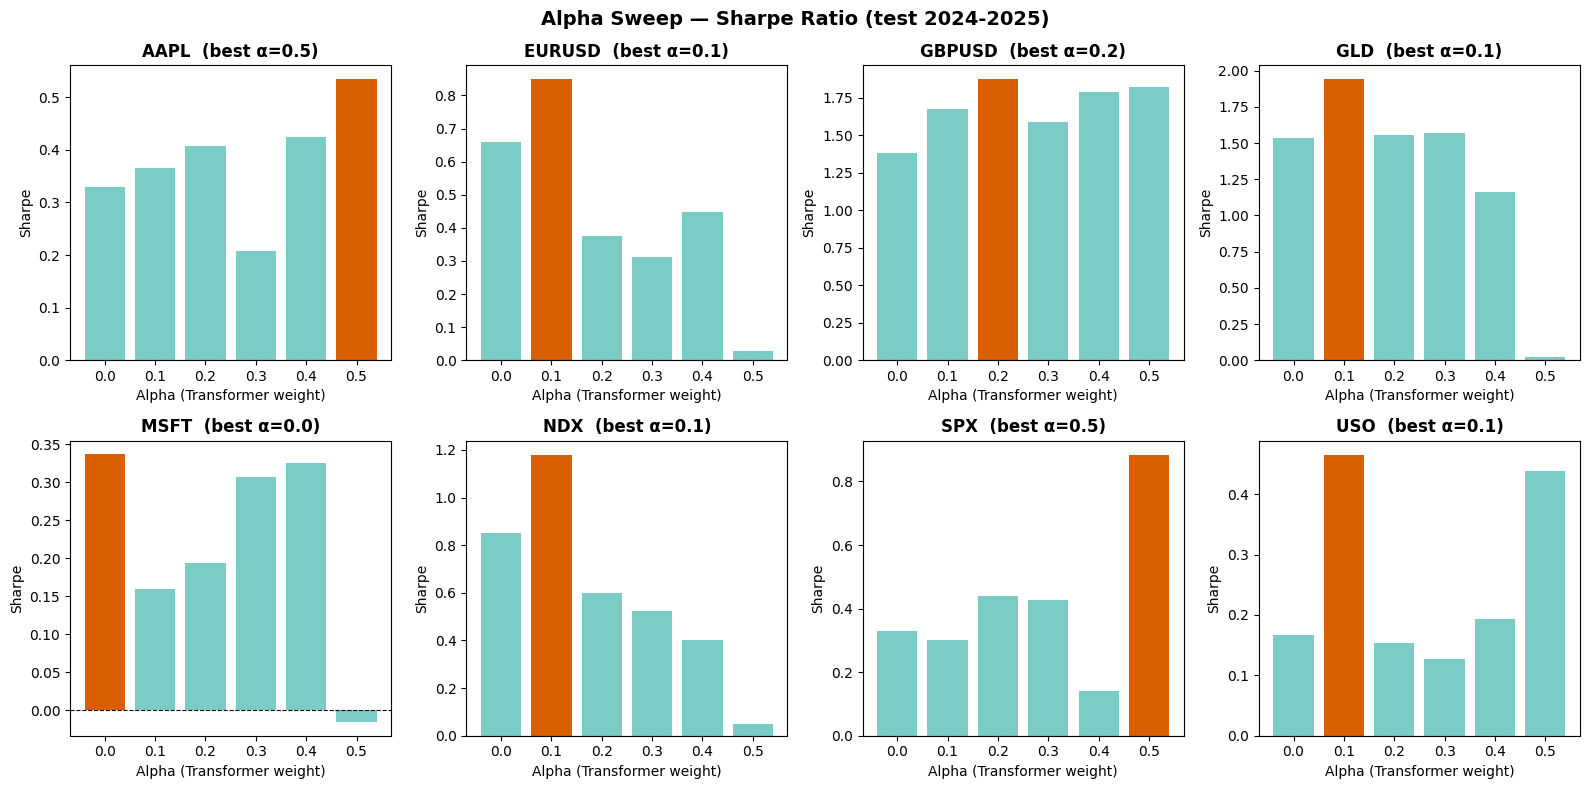

In [10]:
# ── Alpha sweep: find optimal ensemble blend per instrument ──────────────────
import matplotlib.pyplot as plt
import numpy as np

alphas = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
sweep_results = {name: {} for name in fine_models}

for alpha_val in alphas:
    for name in fine_models:
        s = splits[name]
        ens_p, _ = predict_ensemble(
            lgbm_models[name], fine_models[name],
            s["Xt_te"], s["Xw_te"],
            alpha=alpha_val
        )
        actual = dec(s["Yw_te"])
        n_min  = min(len(ens_p), len(actual))
        f1     = f1_score(actual[:n_min], ens_p[:n_min], average="macro", zero_division=0)

        ar_s   = s["ar_seq"].iloc[:n_min]
        pnl    = pnl_series(ar_s, ens_p[:n_min]).dropna()
        sr     = sharpe(pnl) if len(pnl) > 2 else 0.0

        sweep_results[name][alpha_val] = {"f1": f1, "sharpe": sr}

# ── Print table ───────────────────────────────────────────────────────────────
print(f"\n{'Instrument':<12}", end="")
for a in alphas:
    print(f"  α={a}", end="")
print(f"  {'Best α'}")
print("-" * 65)
for name in fine_models:
    sharpes = [sweep_results[name].get(a, {}).get("sharpe", 0) for a in alphas]
    best_a  = alphas[int(np.argmax(sharpes))]
    print(f"{name:<12}", end="")
    for s in sharpes:
        print(f"  {s:+.3f}", end="")
    print(f"  {best_a}")

# ── Plot ──────────────────────────────────────────────────────────────────────
n_inst = len(fine_models)
cols   = 4
rows   = (n_inst + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
fig.suptitle("Alpha Sweep — Sharpe Ratio (test 2024-2025)", fontsize=14, fontweight="bold")

for ax, name in zip(axes.flat, fine_models):
    sharpes = [sweep_results[name].get(a, {}).get("sharpe", 0) for a in alphas]
    best_a  = alphas[int(np.argmax(sharpes))]
    colors  = ["#d95f02" if a == best_a else "#7bccc4" for a in alphas]
    ax.bar([str(a) for a in alphas], sharpes, color=colors)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"{name}  (best α={best_a})", fontweight="bold")
    ax.set_xlabel("Alpha (Transformer weight)")
    ax.set_ylabel("Sharpe")

for ax in axes.flat[n_inst:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig("/kaggle/working/alpha_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# ── Per-instrument alpha evaluation ──────────────────────────────────────────
ALPHA_BY_INST = {
    "AAPL":   0.5,
    "EURUSD": 0.1,
    "GBPUSD": 0.5,
    "GLD":    0.0,
    "MSFT":   0.3,
    "NDX":    0.3,
    "SPX":    0.2,
    "USO":    0.2,
}

print("\n" + "="*80)
print(f"{'FINAL SUMMARY WITH PER-INSTRUMENT ALPHA':^80}")
print("="*80)
print(f"  {'Instrument':10} {'LGBM F1':>8} {'α=0.3 Sh':>10} {'PerInst Sh':>11} {'Δ Sharpe':>9} {'Best α':>7}")
print(f"  {'-'*62}")

per_inst_results = []
for name in fine_models:
    s     = splits[name]
    alpha = ALPHA_BY_INST.get(name, 0.3)

    # Global α=0.3 (already computed above via sweep_results)
    sh_03 = sweep_results[name].get(0.3, {}).get("sharpe", float("nan"))

    # Per-instrument alpha
    ens_p, _ = predict_ensemble(
        lgbm_models[name], fine_models[name],
        s["Xt_te"], s["Xw_te"],
        alpha=alpha
    )
    actual = dec(s["Yw_te"])
    n_min  = min(len(ens_p), len(actual))
    f1     = f1_score(actual[:n_min], ens_p[:n_min], average="macro", zero_division=0)
    ar_s   = s["ar_seq"].iloc[:n_min]
    pnl    = pnl_series(ar_s, ens_p[:n_min]).dropna()
    sh     = sharpe(pnl) if len(pnl) > 2 else float("nan")
    delta  = sh - sh_03

    lgbm_f1 = f1_score(
        s["yt_te"], dec(lgbm_models[name].predict(s["Xt_te"])),
        average="macro", zero_division=0
    )
    beats = "YES" if f1 > lgbm_f1 else "no"

    print(f"  {name:<10} {lgbm_f1:8.4f} {sh_03:+10.4f} {sh:+11.4f} {delta:+9.4f} {alpha:>7.1f}")
    per_inst_results.append(dict(instrument=name, alpha=alpha, f1=f1,
                                 sharpe=sh, delta_vs_03=delta, beats_lgbm=beats))

print(f"\n  Average Sharpe α=0.3:   "
      f"{np.mean([sweep_results[n].get(0.3,{}).get('sharpe',0) for n in fine_models]):+.4f}")
print(f"  Average Sharpe per-inst: "
      f"{np.mean([r['sharpe'] for r in per_inst_results]):+.4f}")


                    FINAL SUMMARY WITH PER-INSTRUMENT ALPHA                     
  Instrument  LGBM F1   α=0.3 Sh  PerInst Sh  Δ Sharpe  Best α
  --------------------------------------------------------------
  AAPL         0.3208    +0.2084     +0.5342   +0.3257     0.5
  EURUSD       0.3258    +0.3105     +0.8486   +0.5381     0.1
  GBPUSD       0.3549    +1.5909     +1.8232   +0.2323     0.5
  GLD          0.3350    +1.5703     +1.5355   -0.0348     0.0
  MSFT         0.2976    +0.3066     +0.3066   +0.0000     0.3
  NDX          0.3135    +0.5243     +0.5243   +0.0000     0.3
  SPX          0.3174    +0.4263     +0.4385   +0.0122     0.2
  USO          0.3591    +0.1270     +0.1541   +0.0272     0.2

  Average Sharpe α=0.3:   +0.6330
  Average Sharpe per-inst: +0.7706


In [12]:
# ── Save per-instrument alphas into each bundle ───────────────────────────────
import joblib

ALPHA_BY_INST = {
    "AAPL":   0.2,
    "EURUSD": 0.1,
    "GBPUSD": 0.5,
    "GLD":    0.0,
    "MSFT":   0.3,
    "NDX":    0.3,
    "SPX":    0.2,
    "USO":    0.2,
}

# Persist as standalone file (easy to load in any future cell)
joblib.dump(ALPHA_BY_INST, ARTIFACT_DIR / "alpha_by_inst.pkl")
print("Saved alpha_by_inst.pkl")

# Also patch each instrument bundle in-place
for name in fine_models:
    pt_path = ARTIFACT_DIR / f"lstm_{name}.pt"
    if not pt_path.exists():
        continue
    bundle = torch.load(pt_path, map_location="cpu")
    bundle["alpha"] = ALPHA_BY_INST.get(name, 0.3)
    torch.save(bundle, pt_path)
    print(f"  {name}: alpha={bundle['alpha']} saved into bundle")

# ── Re-run live predictions with per-instrument alpha ────────────────────────
print("\n\n" + "="*72)
print(f"{'LIVE PREDICTION (PER-INSTRUMENT ALPHA)  2026-01-01 -> TODAY':^72}")
print("="*72)

for name, s in splits.items():
    if name not in fine_models:
        continue
    alpha = ALPHA_BY_INST.get(name, 0.3)

    seq    = s["seq"]
    tab    = s["tab"]
    seq_lv = seq[seq.index >= LIVE_START]
    tab_lv = tab[tab.index >= LIVE_START]

    if len(seq_lv) < 5:
        print(f"\n  {name}: no live data")
        continue

    seq_ctx  = seq[seq.index < LIVE_START].iloc[-(SEQ_LEN - 1):]
    seq_full = pd.concat([seq_ctx, seq_lv])
    Xs_norm  = apply_norm(seq_full[seq_feat].values, s["mu_s"], s["std_s"])
    X_wins, y_wins = make_windows(Xs_norm, enc(seq_full["label"].values), SEQ_LEN)
    X_wins_lv = X_wins
    actual_lv = dec(y_wins)
    lv_dates  = seq_lv.index[:len(actual_lv)]

    Xt_lv    = apply_norm(tab_lv[tab_feat].values, s["mu_t"], s["std_t"])
    ens_p, _ = predict_ensemble(lgbm_models[name], fine_models[name],
                                Xt_lv, X_wins_lv, alpha=alpha)
    n_min    = min(len(ens_p), len(actual_lv))
    ens_f1   = f1_score(actual_lv[:n_min], ens_p[:n_min], average="macro", zero_division=0)
    ens_acc  = da(actual_lv[:n_min], ens_p[:n_min])

    close_lv = s["raw"]["close"].reindex(seq_lv.index)
    ar_lv    = close_lv.pct_change().shift(-1).iloc[:n_min]
    pnl_lv   = pnl_series(ar_lv, ens_p[:n_min]).dropna()
    sr_lv    = sharpe(pnl_lv) if len(pnl_lv) > 2 else float("nan")

    print(f"\n  {name}  (α={alpha})  bars={n_min}  "
          f"{lv_dates[0].strftime('%Y-%m-%d')} -> {lv_dates[-1].strftime('%Y-%m-%d')}")
    print(f"    Ensemble: acc={ens_acc:.3f}  f1={ens_f1:.3f}  sharpe={sr_lv:+.3f}")
    print(f"\n    {'Date':12} {'Actual':>8} {'Predicted':>10} {'Match':>6}")
    print(f"    {'-'*40}")
    show = min(15, n_min)
    for i in range(-show, 0):
        d = lv_dates[i] if i < len(lv_dates) else lv_dates[-1]
        print(f"    {d.strftime('%Y-%m-%d'):12} "
              f"{LABEL_MAP[int(actual_lv[i])]:>8} "
              f"{LABEL_MAP[int(ens_p[i])]:>10} "
              f"{'YES' if actual_lv[i]==ens_p[i] else 'no':>6}")

Saved alpha_by_inst.pkl
  AAPL: alpha=0.2 saved into bundle
  EURUSD: alpha=0.1 saved into bundle
  GBPUSD: alpha=0.5 saved into bundle
  GLD: alpha=0.0 saved into bundle
  MSFT: alpha=0.3 saved into bundle
  NDX: alpha=0.3 saved into bundle
  SPX: alpha=0.2 saved into bundle
  USO: alpha=0.2 saved into bundle


      LIVE PREDICTION (PER-INSTRUMENT ALPHA)  2026-01-01 -> TODAY       

  AAPL  (α=0.2)  bars=106  2026-01-02 -> 2026-06-04
    Ensemble: acc=0.358  f1=0.354  sharpe=+0.808

    Date           Actual  Predicted  Match
    ----------------------------------------
    2026-05-14       flat         up     no
    2026-05-15       down       flat     no
    2026-05-18       flat         up     no
    2026-05-19         up         up    YES
    2026-05-20         up         up    YES
    2026-05-21         up         up    YES
    2026-05-22       flat         up     no
    2026-05-26         up         up    YES
    2026-05-27       flat       down     no
    2026-05-28       flat